In [1]:
import importlib
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch
from scipy.stats import spearmanr, ttest_1samp
from statsmodels.stats.multitest import multipletests

_project_root = str(
    next(
        (
            _p
            for _p in (Path.cwd(), *Path.cwd().parents)
            if (_p / "common.py").is_file()
        ),
        Path.cwd().parent,
    )
)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

warnings.filterwarnings("ignore")

import embeddings
import figure_config

import embedding_utils

importlib.reload(embeddings)
importlib.reload(embedding_utils)
importlib.reload(figure_config)

from embeddings import (
    compute_marker_parameter_correlations,
    get_available_parameters,
    load_dynamic_cytof_data,
    load_embedding_data,
    load_parameter_data,
    plot_binned_dynamic_cytof,
    plot_marker_parameter_barplots,
    prepare_pca_embeddings,
)
from figure_config import (
    CONTEXT_LABELS,
    FONTSIZE,
    FONTSIZE_HEADING,
    LW_MEDIUM,
    LW_THIN,
    MODEL_LABELS,
    configure_axis_spines,
)

from cell_line_annotations import (
    fetch_cbioportal_mutations,
    fetch_cmp_driver_genes,
    get_cellosaurus_annotations,
    load_marcotte_subtypes,
)
from common import basedir, evaluations_dir, features_dir, subtypes_tognetti
from embedding_utils import evaluate_annotation_classifier
from figures_paper.de_corr_plots import draw_corr_barplot, plot_panel_volcano

print("All imports OK")

All imports OK


## Panel helper functions

In [2]:
# --- Shared data loading -----------------------------------------------------

def load_sensitivity_data(kind: str, model: str, dataset: str, figure: str) -> pd.DataFrame:
    """Load sensitivity CSV from eval/{model}/{dataset}/sensitivity_{kind}_{figure}.csv."""
    filepath = basedir / "eval" / model / dataset / f"sensitivity_{kind}_{figure}.csv"
    if not filepath.exists():
        raise FileNotFoundError(f"Sensitivity data not found: {filepath}")
    return pd.read_csv(filepath, index_col=0)


def get_param_sensitivity_order(
    params_df: pd.DataFrame,
    context: str = "cytof_init",
    dataset: str = "val",
) -> list[str]:
    """Return parameter names ordered by descending mean sensitivity."""
    subset = params_df[(params_df["context"] == context) & (params_df["dataset"] == dataset)]
    return (
        subset.groupby("param")["rmse_diff_zeroed"]
        .mean()
        .sort_values(ascending=False)
        .index
        .tolist()
    )


def build_annotation_sources(
    cell_lines: list[str],
    marc: pd.DataFrame,
    min_gene_freq: int = 8,
) -> dict[str, pd.Series]:
    """Collect all usable annotation series for classifier evaluation."""
    annotation_sources: dict[str, pd.Series] = {}

    for col in [
        "subtype_intrinsic",
        "subtype_neve",
        "subtype_claudin_low",
        "subtype_three_receptor",
        "subtype_curtis",
        "subtype_lehmann_tnbc",
        "subtype_marcotte",
        "subtype_rppa",
        "subtype_screen_unsupervised",
    ]:
        if col in marc.columns:
            ser = marc[col].dropna()
            if ser.nunique() >= 2:
                annotation_sources[col] = ser

    for col in ["status_AR", "status_ESR1", "status_ERBB2", "status_PGR"]:
        if col in marc.columns:
            ser = marc[col].dropna()
            if ser.nunique() >= 2:
                annotation_sources[col] = ser

    if "subtype_intrinsic" in marc.columns:
        lb = marc["subtype_intrinsic"].copy()
        lb = lb.replace({
            "LuminalA": "Luminal",
            "LuminalB": "Luminal",
            "HER2": "Luminal",
            "CL": "Basal",
        })
        lb = lb[lb.isin(["Luminal", "Basal"])]
        if lb.nunique() >= 2:
            annotation_sources["luminal_basal"] = lb

    try:
        cello_annot, _, _, _ = get_cellosaurus_annotations(
            cell_lines,
            file_dir=features_dir,
            cache_dir=features_dir,
        )
        for col, label in [
            ("MS_Status", "cellosaurus_MSI"),
            ("Site", "cellosaurus_site"),
            ("Disease", "cellosaurus_disease"),
            ("Population", "cellosaurus_population"),
            ("Category", "cellosaurus_category"),
        ]:
            if col in cello_annot.columns:
                ser = cello_annot[col].replace("Unknown", np.nan).dropna()
                if ser.nunique() >= 2:
                    annotation_sources[label] = ser
        print("Cellosaurus annotations added")
    except Exception as exc:
        print(f"Cellosaurus annotations skipped: {exc}")

    pam50_ser = pd.Series(
        {cl: subtypes_tognetti[cl]["PAM50"] for cl in cell_lines if cl in subtypes_tognetti},
        name="PAM50",
    )
    pam50_ser = pam50_ser[pam50_ser != "Unknown"].dropna()
    if pam50_ser.nunique() >= 2:
        annotation_sources["PAM50_tognetti"] = pam50_ser

    try:
        cbio_df = fetch_cbioportal_mutations(cell_lines, cache_dir=features_dir)
        driver_genes = fetch_cmp_driver_genes(cache_dir=features_dir)

        gene_cl = cbio_df.groupby("gene")["cell_line"].nunique()
        freq_genes = gene_cl[
            (gene_cl >= min_gene_freq) & (gene_cl.index.isin(driver_genes))
        ].index.tolist()
        print(f"cBioPortal driver genes retained: {len(freq_genes)}")

        for gene in sorted(freq_genes):
            mutated_cls = set(cbio_df[cbio_df["gene"] == gene]["cell_line"])
            ser = pd.Series({cl: ("mutated" if cl in mutated_cls else "WT") for cl in cell_lines})
            vc = ser.value_counts()
            if len(vc) >= 2 and vc.min() >= 3:
                annotation_sources[f"cbio_{gene}_mut"] = ser

        tmb = cbio_df.groupby("cell_line")["gene"].nunique().rename("TMB")
        tmb = tmb.reindex(cell_lines, fill_value=0)
        tmb_med = tmb.median()
        tmb_label = tmb.map(lambda value: "TMB_high" if value > tmb_med else "TMB_low")
        if tmb_label.nunique() >= 2:
            annotation_sources["cbio_TMB_highlow"] = tmb_label

        if "mutationType" in cbio_df.columns:
            dom_mt = (
                cbio_df.groupby(["cell_line", "mutationType"]).size()
                .reset_index(name="count")
                .sort_values("count", ascending=False)
                .drop_duplicates(subset="cell_line", keep="first")
                .set_index("cell_line")["mutationType"]
            )
            dom_mt = dom_mt.reindex([cl for cl in cell_lines if cl in dom_mt.index])
            keep = dom_mt.value_counts()
            keep = keep[keep >= 3].index
            dom_mt = dom_mt[dom_mt.isin(keep)]
            if dom_mt.nunique() >= 2:
                annotation_sources["cbio_dominant_muttype"] = dom_mt

        pathway_genes = {
            "PI3K_pathway": {"PIK3CA", "PIK3R1", "AKT1", "PTEN", "MTOR"},
            "TP53_pathway": {"TP53", "MDM2", "ATM", "CHEK2"},
            "MAPK_pathway": {"KRAS", "NRAS", "BRAF", "MAP2K1", "MAP3K1", "NF1"},
            "chromatin_remodeling": {"ARID1A", "KMT2C", "KMT2D", "SETD2"},
        }
        for pathway_name, pathway_members in pathway_genes.items():
            pathway_cls = set(cbio_df[cbio_df["gene"].isin(pathway_members)]["cell_line"])
            ser = pd.Series({cl: ("mutated" if cl in pathway_cls else "WT") for cl in cell_lines})
            vc = ser.value_counts()
            if len(vc) >= 2 and vc.min() >= 3:
                annotation_sources[f"cbio_{pathway_name}"] = ser
        print("cBioPortal annotations added")
    except Exception as exc:
        print(f"cBioPortal annotations skipped: {exc}")

    return annotation_sources


def compute_annotation_classifier_results(
    pca_embedding_df: pd.DataFrame,
    model: str,
    context: str,
    classifiers: tuple[str, ...] = ("svm", "logreg"),
) -> dict[str, object]:
    """Run annotation classifiers once and return summary tables used by multiple panels."""
    if pca_embedding_df.index.name == "cell_line":
        pca_clf_df = pca_embedding_df.reset_index()
    else:
        pca_clf_df = pca_embedding_df.copy()

    cell_lines = sorted(pca_clf_df["cell_line"].unique())
    marc = load_marcotte_subtypes(cell_lines)
    annotation_sources = build_annotation_sources(cell_lines, marc)

    emb = pca_clf_df[
        (pca_clf_df["model"] == model)
        & (pca_clf_df["context"] == context)
    ].copy()

    all_results = []
    all_importances = []

    for annot_name, annot_ser in annotation_sources.items():
        for classifier in classifiers:
            res, imp = evaluate_annotation_classifier(
                embeddings_df=emb,
                annotation_series=annot_ser,
                annotation_name=annot_name,
                classifier=classifier,
                group_cols=["context", "samples"],
                min_class_count=3,
                return_feature_importances=True,
            )
            if not res.empty:
                res["model"] = model
                all_results.append(res)
            if not imp.empty:
                imp["model"] = model
                all_importances.append(imp)

    annot_results_df = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()
    importance_df = pd.concat(all_importances, ignore_index=True) if all_importances else pd.DataFrame()

    for col in ["roc_auc", "macro_f1", "balanced_accuracy", "chance_accuracy", "chance_balanced"]:
        if col not in annot_results_df.columns:
            annot_results_df[col] = np.nan

    annotation_summary_df = (
        annot_results_df
        .groupby(["annotation", "samples"], as_index=False)
        .agg(
            balanced_accuracy=("balanced_accuracy", "mean"),
            balanced_accuracy_std=("balanced_accuracy", "std"),
            chance_balanced=("chance_balanced", "first"),
            n_classes=("n_classes", "first"),
        )
    )
    if not annotation_summary_df.empty:
        annotation_summary_df["above_chance"] = (
            annotation_summary_df["balanced_accuracy"] - annotation_summary_df["chance_balanced"]
        )
        annotation_summary_df = annotation_summary_df.sort_values(
            ["above_chance", "balanced_accuracy"],
            ascending=[False, False],
        )

    annotation_heat_df = pd.DataFrame()
    if not annot_results_df.empty:
        annotation_heat_df = (
            annot_results_df[annot_results_df["samples"] == "all"]
            .groupby(["annotation", "classifier"])["balanced_accuracy"]
            .mean()
            .reset_index()
            .pivot(index="annotation", columns="classifier", values="balanced_accuracy")
        )
        if not annotation_heat_df.empty:
            top_annotations = (
                annotation_heat_df.mean(axis=1)
                .sort_values(ascending=False)
                .head(18)
                .index
            )
            annotation_heat_df = annotation_heat_df.loc[top_annotations]

    return {
        "annotation_sources": annotation_sources,
        "annot_results_df": annot_results_df,
        "importance_df": importance_df,
        "annotation_summary_df": annotation_summary_df,
        "annotation_heat_df": annotation_heat_df,
    }


def load_all_panel_data(
    model: str,
    dataset: str,
    figure: str,
    param_context: str,
    annotation_model: str,
    annotation_context: str,
) -> dict[str, object]:
    """Load and derive all shared data used by downstream notebook panels."""
    params = get_available_parameters(model, figure)
    params_df = load_sensitivity_data("params", model=model, dataset=dataset, figure=figure)
    params_df = params_df[
        (params_df["context"] == param_context)
        & (params_df["samples"] == "all")
    ]
    param_order = get_param_sensitivity_order(
        params_df,
        context=param_context,
        dataset="train",
    )

    train_sub = params_df[params_df["dataset"] == "train"]
    pvals = {}
    for param, grp in train_sub.groupby("param")["rmse_diff_zeroed"]:
        _, pval = ttest_1samp(grp.values, 0)
        pvals[param] = 1.0 if np.isnan(pval) else pval

    pval_series = pd.Series(pvals)
    reject, pval_adj, _, _ = multipletests(pval_series.values, method="fdr_bh")
    pval_df = pd.DataFrame(
        {
            "param": pval_series.index,
            "pval": pval_series.values,
            "pval_adj": pval_adj,
            "reject": reject,
        }
    )
    sig_params = set(pval_df.loc[pval_df["reject"], "param"])
    param_order = [param for param in param_order if param in sig_params]
    top2_params = param_order[:2]

    params_df = params_df.merge(pval_df, on="param", how="left")

    # `data=dataset` is the DATA NAME ("dream_cytof"); the train/val split is a
    # separate axis. The "all" CV split also carries the 5 held-out test cell
    # lines (common.test_samples), so restrict to the 58 training lines.
    embedding_df = load_embedding_data(
        figure=figure, data=dataset, dataset="train"
    )
    subtypes_df = load_marcotte_subtypes(embedding_df.cell_line.unique())
    pca_embedding_df = prepare_pca_embeddings(embedding_df, subtypes_df)

    annotation_payload = compute_annotation_classifier_results(
        pca_embedding_df=pca_embedding_df,
        model=annotation_model,
        context=annotation_context,
    )

    return {
        "params": params,
        "params_df": params_df,
        "param_order": param_order,
        "top2_params": top2_params,
        "pval_df": pval_df,
        "sig_params": sig_params,
        "embedding_df": embedding_df,
        "subtypes_df": subtypes_df,
        "pca_embedding_df": pca_embedding_df,
        **annotation_payload,
    }


# --- Axis-level panel renderers ---------------------------------------------

# plot_top_marker_correlations replaced by draw_corr_barplot from figures_paper.de_corr_plots


def shorten_label(label: str, max_len: int = 30) -> str:
    """Shorten long parameter names for panel titles."""
    if len(label) <= max_len:
        return label
    return label[: max_len - 1] + "…"

In [3]:
# --- Shared formatting helpers ------------------------------------------------


def plot_heatmap_panel(
    ax,
    heatmap_df: pd.DataFrame,
    title: str,
    cmap: str,
    vmin: float,
    vmax: float,
    center: float | None = None,
    cbar: bool = True,
    cbar_kws: dict | None = None,
    xrotation: int = 45,
    yrotation: int = 0,
    show_yticklabels: bool = True,
    mask: np.ndarray | None = None,
):
    """Render a styled heatmap panel with shared annotation and tick formatting."""
    sns.heatmap(
        heatmap_df,
        annot=True,
        fmt=".1f",
        cmap=cmap,
        center=center,
        vmin=vmin,
        vmax=vmax,
        linewidths=0.5,
        linecolor="white",
        cbar=cbar,
        cbar_kws=cbar_kws,
        ax=ax,
        annot_kws={"fontsize": FONTSIZE},
        mask=mask,
    )
    ax.set_title(title, fontsize=FONTSIZE_HEADING)
    ax.tick_params(axis="x", rotation=xrotation, labelsize=FONTSIZE)
    ax.tick_params(axis="y", rotation=yrotation, labelsize=FONTSIZE)
    ax.grid(False)
    if not show_yticklabels:
        ax.set_yticklabels([])
    ax.set_xlabel("")
    ax.set_ylabel("")


def build_significance_legend_handles() -> list[Patch]:
    """Return the shared marker-correlation legend handles."""
    return [
        Patch(facecolor="firebrick", edgecolor="black", linewidth=LW_THIN, label="FDR<0.05 (+)"),
        Patch(facecolor="steelblue", edgecolor="black", linewidth=LW_THIN, label="FDR<0.05 (-)"),
        Patch(facecolor="lightcoral", edgecolor="black", linewidth=LW_THIN, label="FDR≥0.05 (+)"),
        Patch(facecolor="lightsteelblue", edgecolor="black", linewidth=LW_THIN, label="FDR≥0.05 (-)"),
    ]

## Load all data

In [4]:
MODEL = "EGFR_MAPK__logobs_tegfr_aggavg"
DATASET = "dream_cytof"
FIGURE = "figure1a"
PARAM_CONTEXT = "cytof_init"
SENSITIVITY_DATASETS = ("train", "val")

ANNOTATION_MODEL = "EGFR_MAPK__logobs"
ANNOTATION_CONTEXT = "multimodal"
ANNOTATION_CLASSIFIERS = ("svm", "logreg")

COMPOSITE_SAMPLE_GROUP = "all"
PANEL_CORR_TYPES = ["transcriptomics", "proteomics", "cytof"]
STRATIFY_LB = False  # set True to run correlation analysis per Luminal/Basal subgroup
COMPOSITE_CORR_TYPES = [
    ("transcriptomics", "RNAseq"),
    ("proteomics", "MassSpec"),
    ("cytof", "CyTOF"),
]
COMPOSITE_DE_TYPES = [
    ("transcriptomics", "RNAseq"),
    ("proteomics", "MassSpec"),
]

model_label = MODEL_LABELS.get(MODEL, MODEL)
annotation_model_label = MODEL_LABELS.get(ANNOTATION_MODEL, ANNOTATION_MODEL)

panel_data = load_all_panel_data(
    model=MODEL,
    dataset=DATASET,
    figure=FIGURE,
    param_context=PARAM_CONTEXT,
    annotation_model=ANNOTATION_MODEL,
    annotation_context=ANNOTATION_CONTEXT,
)

params = panel_data["params"]
params_df = panel_data["params_df"]
param_order = panel_data["param_order"]
top2_params = panel_data["top2_params"]
pval_df = panel_data["pval_df"]
sig_params = panel_data["sig_params"]
embedding_df = panel_data["embedding_df"]
subtypes_df = panel_data["subtypes_df"]
pca_embedding_df = panel_data["pca_embedding_df"]
annotation_sources = panel_data["annotation_sources"]
annot_results_df = panel_data["annot_results_df"]
importance_df = panel_data["importance_df"]
annotation_summary_df = panel_data["annotation_summary_df"]
annotation_heat_df = panel_data["annotation_heat_df"]

composite_top_n_sensitivity = min(7, len(param_order))
composite_top_n_marker_corr = 10
composite_top_n_annotations = 8
composite_save_path = Path.cwd() / "composite_embeddings_parameters_tegfr_cytof.pdf"

pathway_parameter_order = {
    "ERBB2_p_Y1248_ERBB2_kw": 0,
    "MEK_p_S222_ERBB2__Y1248_p_kw": 1,
    "ERK_p_Y204_MEK__S222_p_kw": 2,
    "RPS6KA1_p_S380_ERK__Y204_p_kw": 3,
}
composite_params = sorted(
    top2_params[:4],
    key=lambda parameter: pathway_parameter_order.get(parameter, 999),
)

param_arrow_labels = {
    "ERBB2_p_Y1248_ERBB2_kw": "→ p.ERBB2",
    "MEK_p_S222_ERBB2__Y1248_p_kw": "p.ERBB2 → p.MEK",
    "ERK_p_Y204_MEK__S222_p_kw": "p.MEK → p.ERK",
    "RPS6KA1_p_S380_ERK__Y204_p_kw": "p.ERK → p.RSK",
    "ERK_p_Y204_iMEK_0_kw": "iMEK -| p.ERK",
    "ERBB2_p_Y1248_EGFR__Y1173_p_kw": "p.EGFR → p.ERBB2",
    "MEK_p_S222_EGFR__Y1173_p_kw": "p.EGFR → p.MEK",
    "MEK_p_S222_ERK__Y204_p_kw": "p.ERK -| p.MEK",
}
composite_param_labels = [param_arrow_labels.get(p, p) for p in composite_params]

parameter_marker_pairs = {
    "ERBB2_p_Y1248_ERBB2_kw": ("p.ERBB2", "p.ERK"),
    "MEK_p_S222_ERBB2__Y1248_p_kw": ("p.ERBB2", "p.MEK"),
    "ERK_p_Y204_MEK__S222_p_kw": ("p.MEK", "p.ERK"),
    "RPS6KA1_p_S380_ERK__Y204_p_kw": ("p.ERK", "p.p90RSK"),
    "MEK_p_S222_ERK__Y204_p_kw": ("p.ERK", "p.MEK"),
}

# Reference genes drawn as labeled vertical dashed lines in the correlation barplots.
# Top row (pERBB2): ERBB2 transcripts and proteins; bottom row (pp90RSK): RSK1-3.
parameter_reference_genes = {
    "ERBB2_p_Y1248_ERBB2_kw": ["ERBB2"],
    "RPS6KA1_p_S380_ERK__Y204_p_kw": ["RPS6KA1", "RPS6KA2", "RPS6KA3"],
}

parameter_conditions = {
    "ERBB2_p_Y1248_ERBB2_kw": ["EGF", "iEGFR"],
    "MEK_p_S222_ERBB2__Y1248_p_kw": ["EGF", "iEGFR"],
    "ERK_p_Y204_MEK__S222_p_kw": ["EGF", "iMEK"],
    "RPS6KA1_p_S380_ERK__Y204_p_kw": ["EGF", "iMEK"],
}

BIN_COLORS = {"Low": "#2166AC", "High": "#B2182B"}
SIM_COLORS = {"Low": "#6BAED6", "High": "#FC9272"}

# Observable display name → trajectory observable name
OBS_TO_TRAJ = {
    "p.ERBB2": "pERBB2_Y1248_obs",
    "p.ERK": "pERK_Y204_obs",
    "p.MEK": "pMEK_S222_obs",
    "p.p90RSK": "pRPS6KA1_S380_obs",
}

# Sensitivity: rank by mean sensitivity and apply compact labels to every selected parameter.
sensitivity_order = param_order[:composite_top_n_sensitivity]
sensitivity_df = params_df[
    (params_df["context"] == PARAM_CONTEXT)
    & (params_df["dataset"].isin(SENSITIVITY_DATASETS))
    & (params_df["param"].isin(sensitivity_order))
] .copy()

sensitivity_labels = {}
for idx, parameter in enumerate(sensitivity_order, start=1):
    base_label = param_arrow_labels.get(parameter, shorten_label(parameter, max_len=18))
    sensitivity_labels[parameter] = f"P{idx}: {base_label}"


print(f"Available parameters ({len(params)}):")
print(params[:20])
print(f"\nSignificant parameters (BH-corrected p < 0.05): {len(sig_params)} / {len(pval_df)}")
print("Top-2 sensitive parameters:", top2_params)
print(f"Annotation model/context: {annotation_model_label} / {ANNOTATION_CONTEXT}")
print(f"Total annotation sources: {len(annotation_sources)}")
print(f"Total classification results: {len(annot_results_df)} rows")
print(f"Annotations evaluated: {annot_results_df['annotation'].nunique() if not annot_results_df.empty else 0}")
display(pval_df.sort_values("pval").head(20))
if not annotation_summary_df.empty:
    display(annotation_summary_df.head(20))

  [cache hit] Cellosaurus annotations loaded from cache
Cellosaurus annotations added
  [cache hit] cBioPortal mutations loaded from cache
  [cache hit] 791 CMP driver genes loaded from cache
cBioPortal driver genes retained: 21
cBioPortal annotations added
Available parameters (44):
['ERBB3_dp_Y1289_kcat', 'ERBB2_dp_Y1248_kcat', 'EGFR_deg_kdeg', 'EGFR_dp_Y1173_kcat', 'EGFR_recycle_kcat', 'MEK_dp_S222_kcat', 'TOPK_dp_Y74_kcat', 'ERK_dp_Y204_kcat', 'RPS6KA1_dp_S380_kcat', 'ERBB3_p_Y1289_bact', 'ERBB3_p_Y1289_serum_0_kw', 'ERBB2_p_Y1248_bact', 'ERBB2_p_Y1248_ERBB2_kw', 'ERBB2_p_Y1248_EGFR__Y1173_p_kw', 'ERBB2_p_Y1248_ERBB3__Y1289_p_kw', 'ERBB2_p_Y1248_serum_0_kw', 'ERBB2_p_Y1248_iEGFR_0_kw', 'EGFR_p_Y1173_bact', 'EGFR_p_Y1173_EGF_0_kw', 'EGFR_p_Y1173_serum_0_kw']

Significant parameters (BH-corrected p < 0.05): 6 / 44
Top-2 sensitive parameters: ['RPS6KA1_p_S380_ERK__Y204_p_kw', 'ERBB2_p_Y1248_ERBB2_kw']
Annotation model/context: DMM / multimodal
Total annotation sources: 46
Total classi

,param,pval,pval_adj,reject
37,RPS6KA1_p_S380_ERK__Y204_p_kw,0.000009,0.000387,True
28,ERK_p_Y204_iMEK_0_kw,0.000125,0.002747,True
14,ERBB2_p_Y1248_EGFR__Y1173_p_kw,0.001144,0.016773,True
15,ERBB2_p_Y1248_ERBB2_kw,0.001581,0.017390,True
30,MEK_p_S222_EGFR__Y1173_p_kw,0.002996,0.026362,True
33,MEK_p_S222_ERK__Y204_p_kw,0.005839,0.042818,True
25,ERK_p_Y204_MEK__S222_p_kw,0.008863,0.051516,False
10,EGFR_p_Y1173_iEGFR_0_kw,0.009505,0.051516,False
31,MEK_p_S222_ERBB2__Y1248_p_kw,0.010537,0.051516,False
19,ERBB2_p_Y1248_serum_0_kw,0.037058,0.162004,False


,annotation,samples,balanced_accuracy,balanced_accuracy_std,chance_balanced,n_classes,above_chance
32,luminal_basal,all,0.951429,0.000000,0.500000,2,0.451429
41,subtype_marcotte,all,0.600000,0.007857,0.166667,6,0.433333
0,PAM50_tognetti,all,0.623333,0.042426,0.200000,5,0.423333
33,status_AR,all,0.860714,0.011785,0.500000,2,0.360714
35,status_ESR1,all,0.780556,0.017678,0.500000,2,0.280556
34,status_ERBB2,all,0.772778,0.030641,0.500000,2,0.272778
31,cellosaurus_site,all,0.516369,0.016836,0.250000,4,0.266369
28,cellosaurus_category,all,0.763344,0.006547,0.500000,2,0.263344
42,subtype_neve,all,0.510417,0.038302,0.250000,4,0.260417
15,cbio_PDE4DIP_mut,all,0.755000,0.022499,0.500000,2,0.255000


## Panel B — Parameter sensitivity distributions

Parameter data (880 rows) from 2 splits, 1 contexts, 44 total parameters and 10 unique optimisation runs.


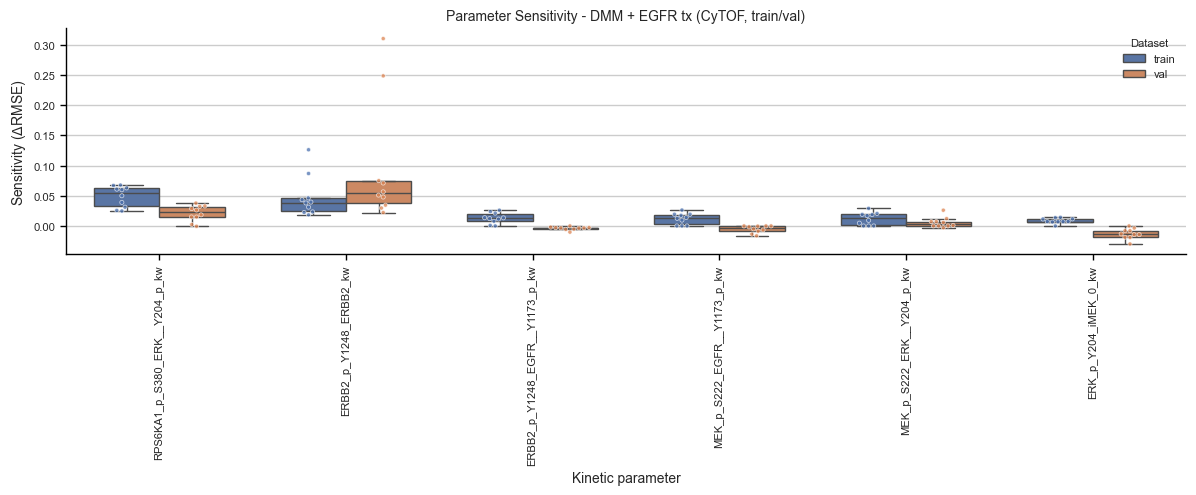

In [5]:
subset = params_df[
    (params_df["context"] == PARAM_CONTEXT)
    & (params_df["dataset"].isin(SENSITIVITY_DATASETS))
].copy()

order = [param for param in param_order if param in subset["param"].unique()]
order = order[:10]
subset = subset[subset["param"].isin(order)]

context_label = CONTEXT_LABELS.get(PARAM_CONTEXT, PARAM_CONTEXT)
dataset_label = "/".join(SENSITIVITY_DATASETS)

use_hue = len(SENSITIVITY_DATASETS) > 1
hue_kwargs = {"hue": "dataset", "hue_order": list(SENSITIVITY_DATASETS)} if use_hue else {}

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=subset,
    x="param",
    y="rmse_diff_zeroed",
    order=order,
    showfliers=False,
    width=0.7,
    linewidth=LW_MEDIUM,
    ax=ax,
    **hue_kwargs,
)
sns.swarmplot(
    data=subset,
    x="param",
    y="rmse_diff_zeroed",
    order=order,
    dodge=use_hue,
    size=3,
    alpha=0.75,
    linewidth=LW_THIN,
    edgecolor="white",
    ax=ax,
    **hue_kwargs,
)

ax.set_ylabel(r"Sensitivity ($\Delta$RMSE)", fontsize=FONTSIZE_HEADING)
ax.set_xlabel("Kinetic parameter", fontsize=FONTSIZE_HEADING)
ax.set_title(
    f"Parameter Sensitivity - {model_label} ({context_label}, {dataset_label})",
    fontsize=FONTSIZE_HEADING,
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.tick_params(axis="both", labelsize=FONTSIZE)

if use_hue:
    handles, labels = ax.get_legend_handles_labels()
    n_labels = len(SENSITIVITY_DATASETS)
    ax.legend(
        handles[:n_labels],
        labels[:n_labels],
        title="Dataset",
        fontsize=FONTSIZE,
        title_fontsize=FONTSIZE,
        frameon=False,
    )

configure_axis_spines(ax)
fig.tight_layout()

print(f"Parameter data ({len(params_df)} rows) from {params_df['dataset'].nunique()} splits, {params_df['context'].nunique()} contexts, {params_df['param'].nunique()} total parameters and {params_df['job'].nunique()} unique optimisation runs.")


CyTOF dynamic matrix: (63, 137)
PCA: using 5/20 PCs to reach 80.6% cumulative variance
Shared cell lines (CyTOF × parameters): 63


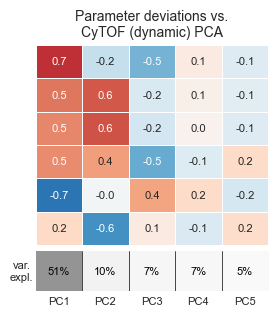

,RPS6KA1_p_S380_ERK__Y204_p_kw,ERBB2_p_Y1248_ERBB2_kw,ERBB2_p_Y1248_EGFR__Y1173_p_kw,MEK_p_S222_EGFR__Y1173_p_kw,MEK_p_S222_ERK__Y204_p_kw,ERK_p_Y204_iMEK_0_kw
cell_line,,,,,,
c184A1,-0.838096,-0.327939,-0.397373,-0.814698,0.784797,0.343322
c184B5,-1.181700,0.218965,0.344598,0.286947,0.502188,-0.729925
cAU565,0.640867,-0.221767,-0.254208,0.583448,-1.207137,0.783544
cBT20,1.090707,0.946467,0.914518,0.528138,-1.323696,0.567680
cBT474,-1.452902,2.211649,1.973212,0.591144,0.176147,-1.948299
...,...,...,...,...,...,...
cUACC812,0.331962,-0.327739,-0.327425,-0.339816,0.338830,0.282040
cUACC893,-2.180639,-1.588251,-1.615744,-1.318734,1.294021,0.675740
cZR751,1.015659,0.440150,0.371080,-0.122997,0.226599,-0.368941


In [6]:
def _plot_cytof_pca_correlation(
    corr_mtx_labeled: pd.DataFrame,
    strip_ve: np.ndarray,
    pc_cols: list,
    ax=None,
) -> plt.Figure:
    """
    Render the CyTOF PCA × parameter-deviation correlation heatmap together
    with a labelled cumulative-variance strip.

    Parameters
    ----------
    corr_mtx_labeled : DataFrame, shape (n_pcs, n_params)
        Spearman ρ; columns are short parameter labels.
    strip_ve : 1-D array, length n_pcs
        explained variance for the plotted PCs (values in [0, 1]).
    pc_cols : list[str]
        PC tick labels ('PC1', 'PC2', …).
    ax : matplotlib Axes, optional
        Axes to draw into.  Must have been created from a GridSpec subplot spec
        (i.e. via ``fig.add_subplot``).  The axes is replaced by two sub-axes
        that fill the same subplot cell (heat on top, variance strip below).
        When *None* (default) a new figure is created.
    """
    n_plot = len(pc_cols)

    if ax is None:
        fig = plt.figure(figsize=(3, 3.2))
        gs = _mgs.GridSpec(2, 1, height_ratios=[10, 2], hspace=0.05, figure=fig)
        ax_heat = fig.add_subplot(gs[0])
        ax_strip = fig.add_subplot(gs[1], sharex=ax_heat)
    else:
        fig = ax.get_figure()
        sub_gs = _mgs.GridSpecFromSubplotSpec(
            2, 1,
            subplot_spec=ax.get_subplotspec(),
            height_ratios=[10, 2],
            hspace=0.05,
        )
        ax.remove()
        ax_heat = fig.add_subplot(sub_gs[0])
        ax_strip = fig.add_subplot(sub_gs[1], sharex=ax_heat)

    # ── Heatmap (value-annotated, consistent with other heatmaps) ──────────
    plot_heatmap_panel(
        ax_heat,
        corr_mtx_labeled.T,
        title="Parameter deviations vs.\nCyTOF (dynamic) PCA",
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        center=0,
        cbar=False,
        xrotation=0,
        yrotation=0,
    )
    # Suppress heatmap x-axis; PC labels live on the strip below
    ax_heat.set_xticks([])
    ax_heat.set_xticklabels([])
    ax_heat.set_yticklabels([])
    ax_heat.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

    # ── Cumulative-variance strip ───────────────────────────────────────────
    heatmap_xlim = ax_heat.get_xlim()
    ax_strip.imshow(
        strip_ve.reshape(1, -1),
        aspect="auto",
        cmap="Greys",
        vmin=0,
        vmax=1,
        extent=[heatmap_xlim[0], heatmap_xlim[1], 0, 1],
    )

    x_centers = [j + 0.5 for j in range(n_plot)]
    ax_strip.set_xticks(x_centers)
    ax_strip.set_xticklabels(pc_cols, fontsize=FONTSIZE, ha="center")
    ax_strip.set_yticks([])
    ax_strip.tick_params(length=0)
    ax_strip.grid(False)
    ax_strip.set_ylabel(
        "var.\nexpl.", fontsize=FONTSIZE, rotation=0, va="center", labelpad=10
    )
    sns.despine(ax=ax_strip, left=True, bottom=True, top=True, right=True)

    # Column dividers in strip
    for xc in x_centers[1:]:
        ax_strip.axvline(xc - 0.5, color="black", linewidth=LW_THIN, zorder=4)

    # CVE percentage labels on each strip cell
    for xc, cve in zip(x_centers, strip_ve):
        text_color = "white" if cve > 0.55 else "black"
        ax_strip.text(
            xc, 0.5, f"{cve:.0%}",
            ha="center", va="center",
            fontsize=FONTSIZE, color=text_color,
            zorder=5,
        )

    # Re-suppress heatmap x-ticks (sharex can propagate the FixedLocator back)
    ax_heat.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

    if ax is None:
        fig.tight_layout()
        # Realign strip width to heatmap after layout (colorbar presence can shift things)
        heat_pos = ax_heat.get_position()
        strip_pos = ax_strip.get_position()
        ax_strip.set_position([heat_pos.x0, strip_pos.y0, heat_pos.width, strip_pos.height])

    return fig


# ── Dynamic CyTOF PCA × parameter-deviation correlation ───────────────────
import matplotlib.gridspec as _mgs
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer

from cytof import get_samples
from dmm.config_options import Conf
from dmm.feature_selection import contextualize_measurements
from util import load_petab_base_files

# ── 1. Load & decompose dynamic CyTOF trajectories ─────────────────────────
_cytof_conf = Conf(model=ANNOTATION_MODEL, data=DATASET)
_cytof_files = load_petab_base_files(_cytof_conf)
_cytof_samples = sorted(
    load_embedding_data(
        figure=FIGURE, data=DATASET, dataset="train"
    ).cell_line.unique()
)

_cytof_mat, _ = contextualize_measurements(
    measurement_table=_cytof_files["measurement_table"],
    observable_table=_cytof_files["observable_table"],
    contextualization="cytof_dynamic",
    samples=_cytof_samples,
    impute=False,
)
print(f"CyTOF dynamic matrix: {_cytof_mat.shape}")

_cytof_X = KNNImputer().fit_transform(_cytof_mat.values)
_cytof_n = min(20, _cytof_X.shape[0] - 1, _cytof_X.shape[1])
_cytof_pca = PCA(n_components=_cytof_n)
_cytof_Xt = _cytof_pca.fit_transform(_cytof_X)
_cytof_ve = _cytof_pca.explained_variance_ratio_

_cytof_cumve_all = np.cumsum(_cytof_ve)
_n_plot = int(np.searchsorted(_cytof_cumve_all, 0.80)) + 1
_n_plot = min(_n_plot, _cytof_n)
print(f"PCA: using {_n_plot}/{_cytof_n} PCs to reach "
      f"{_cytof_cumve_all[_n_plot - 1]:.1%} cumulative variance")

_cytof_pca_df = pd.DataFrame(
    _cytof_Xt[:, :_n_plot],
    index=_cytof_mat.index,
    columns=[f"PC{j + 1}" for j in range(_n_plot)],
)

# ── 2. Load parameter deviations ────────────────────────────────────────────
_param_list_cytof = param_order

_cytof_param_df = pd.concat(
    [
        load_parameter_data(MODEL, p, figure=FIGURE, data=DATASET, context=PARAM_CONTEXT, z_transform=True, dataset="train")
        for p in _param_list_cytof
    ],
    axis=1,
)
_cytof_param_df.columns = _param_list_cytof

# ── 3. Align cell lines and compute Spearman ρ ──────────────────────────────
_cytof_common = sorted(set(_cytof_pca_df.index) & set(_cytof_param_df.index))
print(f"Shared cell lines (CyTOF × parameters): {len(_cytof_common)}")

_pca_sub_cytof = _cytof_pca_df.loc[_cytof_common]
_par_sub_cytof = _cytof_param_df.loc[_cytof_common]

_pc_cols_cytof = [f"PC{j + 1}" for j in range(_n_plot)]
_corr_mtx = pd.DataFrame(index=_pc_cols_cytof, columns=_param_list_cytof, dtype=float)
for _pc in _pc_cols_cytof:
    for _par in _param_list_cytof:
        _rho_val, _ = spearmanr(_pca_sub_cytof[_pc].values, _par_sub_cytof[_par].values)
        _corr_mtx.loc[_pc, _par] = _rho_val

_p_short_labels = {p: sensitivity_labels[p].split(":")[0] for p in _param_list_cytof}
_corr_mtx_labeled = _corr_mtx.rename(columns=_p_short_labels)

# ── 4. Render ────────────────────────────────────────────────────────────────
_fig_cytof = _plot_cytof_pca_correlation(
    corr_mtx_labeled=_corr_mtx_labeled,
    strip_ve=_cytof_ve[:_n_plot],
    pc_cols=_pc_cols_cytof,
)
plt.show()


display(_cytof_param_df)

## Panel C — Binned dynamic CyTOF by sensitive parameters

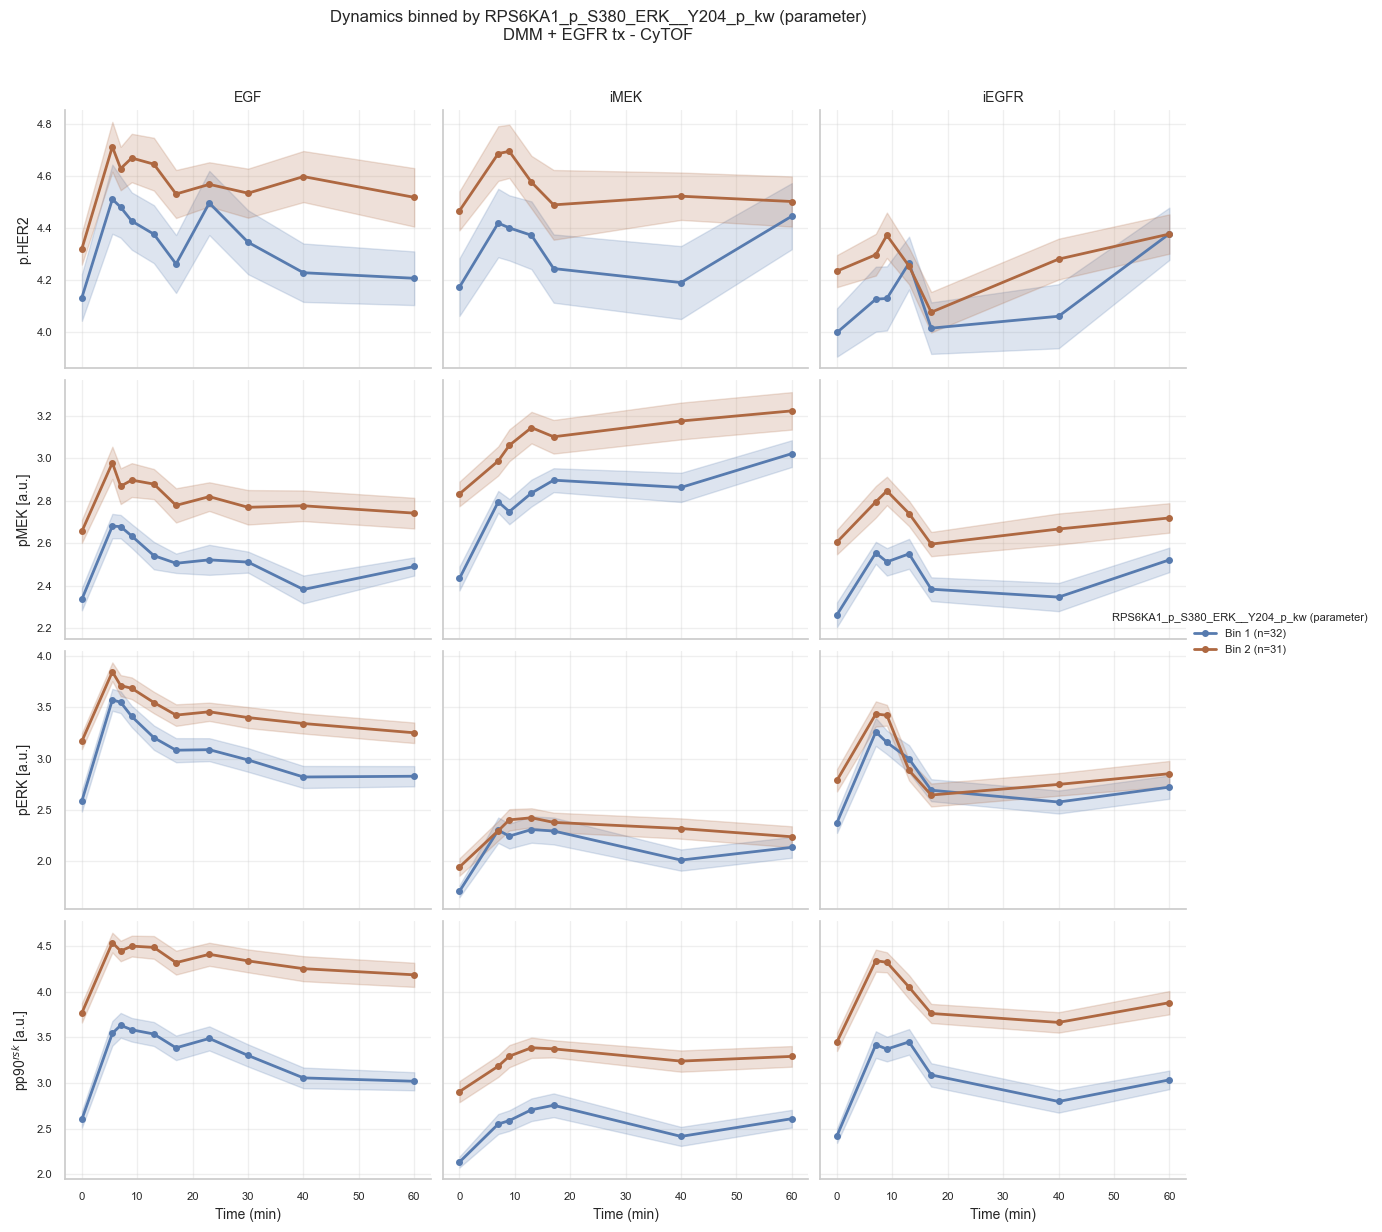

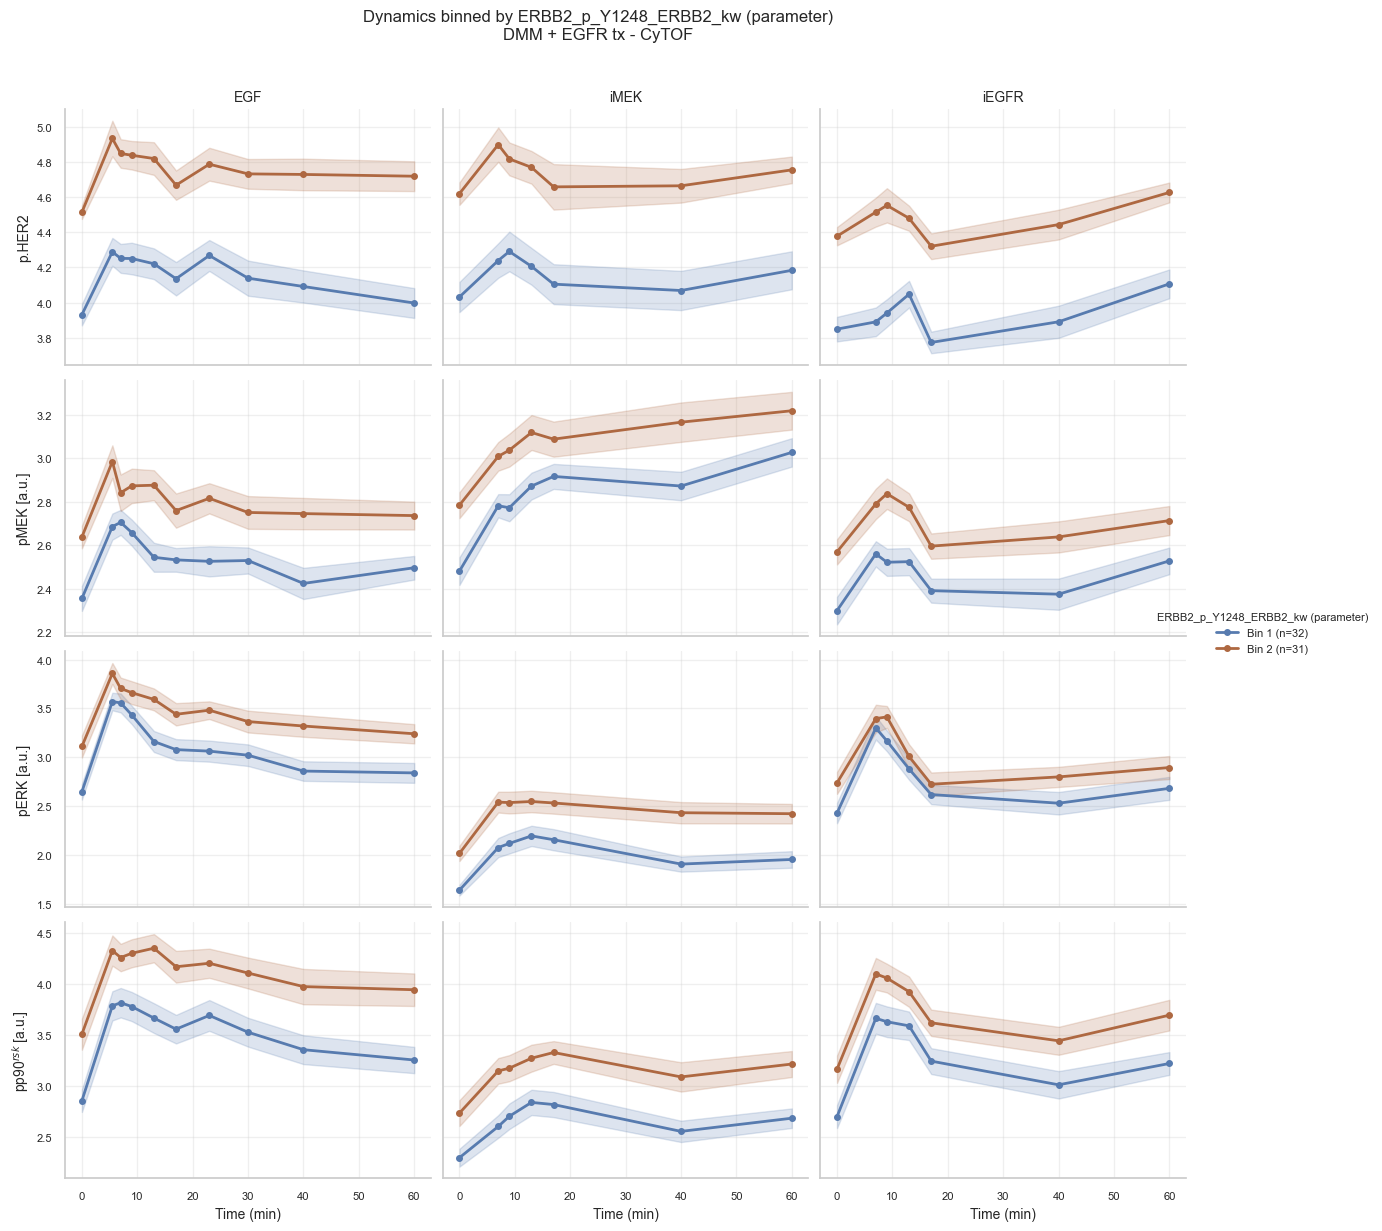

In [7]:
for parameter in top2_params:
    plot_binned_dynamic_cytof(
        model=MODEL,
        context=PARAM_CONTEXT,
        observables=["p.HER2", "p.MEK", "p.ERK", "p.p90RSK"],
        conditions=["EGF", "iMEK", "iEGFR"],
        bin_by=parameter,
        bin_by_type="parameter",
        n_bins=2,
        dataset="train",
        figure=FIGURE,
    );

## Panel D — Marker/parameter correlations

Pre-filtered transcriptomics: 16562 → 12143 genes with median expression > -2.5 (log2 CPM)
Pre-filtered proteomics: 7877 → 6762 genes with dropout in ≤50% of samples


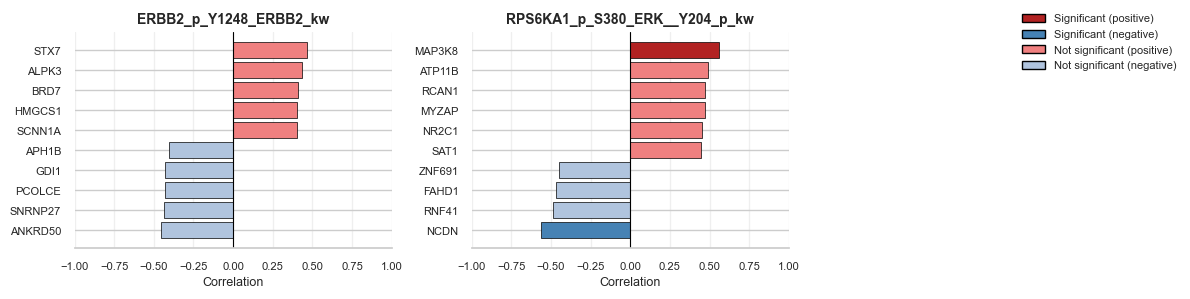

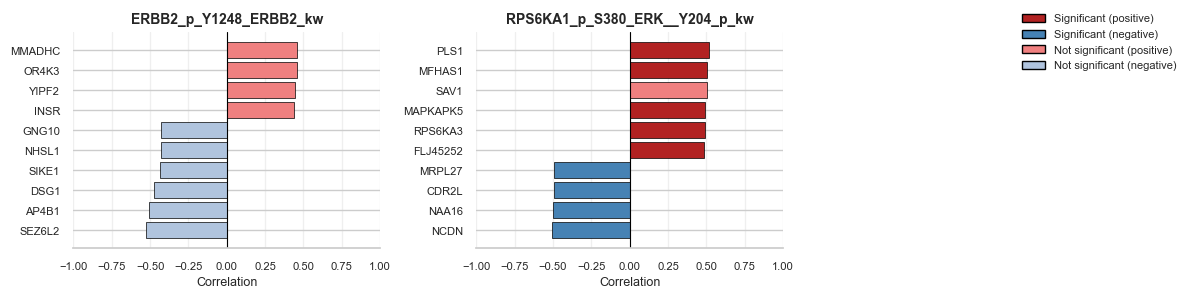

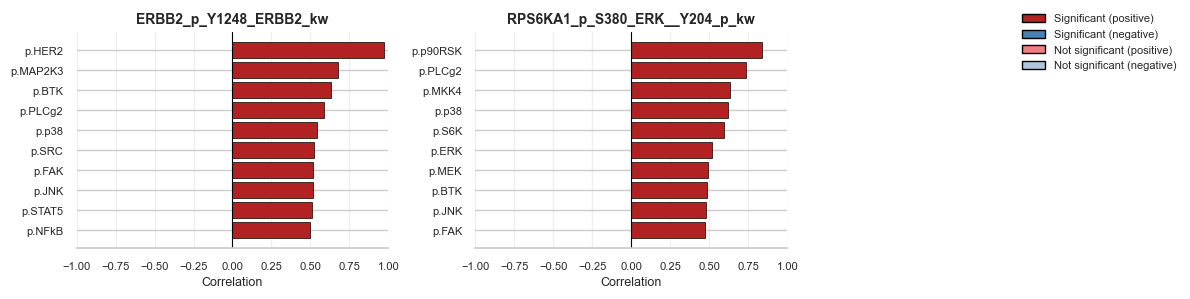

In [8]:
corr_results = {}
for data_type in PANEL_CORR_TYPES:
    corr_results[data_type] = compute_marker_parameter_correlations(
        model=MODEL,
        context=PARAM_CONTEXT,
        parameters=composite_params,
        data_type=data_type,
        method="pearson",
        figure=FIGURE,
        stratify_luminal_basal=STRATIFY_LB,
    )
    plot_marker_parameter_barplots(
        corr_results[data_type],
        parameters=composite_params,
        n_top=10,
        save_path=f"correlation_barplots_{data_type}.pdf",
    )

In [9]:
for data_type in PANEL_CORR_TYPES:
    for parameter in top2_params:
        print(f"\nTop correlations for {parameter} in {data_type}:")
        display(corr_results[data_type].query(f"parameter == '{parameter}'").sort_values("abs_corr", key=abs, ascending=False).head(20))


Top correlations for RPS6KA1_p_S380_ERK__Y204_p_kw in transcriptomics:


,marker,parameter,correlation,pvalue,n_samples,subtype,pvalue_corrected,significant,abs_corr
12697,NCDN,RPS6KA1_p_S380_ERK__Y204_p_kw,-0.561014,0.000002,63,All,0.012049,True,0.561014
11197,MAP3K8,RPS6KA1_p_S380_ERK__Y204_p_kw,0.558350,0.000002,63,All,0.012049,True,0.558350
1639,ATP11B,RPS6KA1_p_S380_ERK__Y204_p_kw,0.491176,0.000044,63,All,0.154185,False,0.491176
16981,RNF41,RPS6KA1_p_S380_ERK__Y204_p_kw,-0.487469,0.000051,63,All,0.154185,False,0.487469
16497,RCAN1,RPS6KA1_p_S380_ERK__Y204_p_kw,0.472304,0.000093,63,All,0.176314,False,0.472304
6659,FAHD1,RPS6KA1_p_S380_ERK__Y204_p_kw,-0.470310,0.000100,63,All,0.176314,False,0.470310
12507,MYZAP,RPS6KA1_p_S380_ERK__Y204_p_kw,0.470016,0.000102,63,All,0.176314,False,0.470016
13307,NR2C1,RPS6KA1_p_S380_ERK__Y204_p_kw,0.454629,0.000182,63,All,0.211768,False,0.454629
23975,ZNF691,RPS6KA1_p_S380_ERK__Y204_p_kw,-0.450912,0.000208,63,All,0.211768,False,0.450912
17559,SAT1,RPS6KA1_p_S380_ERK__Y204_p_kw,0.445305,0.000255,63,All,0.211768,False,0.445305



Top correlations for ERBB2_p_Y1248_ERBB2_kw in transcriptomics:


,marker,parameter,correlation,pvalue,n_samples,subtype,pvalue_corrected,significant,abs_corr
19664,STX7,ERBB2_p_Y1248_ERBB2_kw,0.463909,0.000128,63,All,0.903382,False,0.463909
930,ANKRD50,ERBB2_p_Y1248_ERBB2_kw,-0.454177,0.000185,63,All,0.903382,False,0.454177
18944,SNRNP27,ERBB2_p_Y1248_ERBB2_kw,-0.435765,0.000357,63,All,0.903382,False,0.435765
764,ALPK3,ERBB2_p_Y1248_ERBB2_kw,0.431375,0.000416,63,All,0.903382,False,0.431375
14096,PCOLCE,ERBB2_p_Y1248_ERBB2_kw,-0.429614,0.000442,63,All,0.903382,False,0.429614
7770,GDI1,ERBB2_p_Y1248_ERBB2_kw,-0.428484,0.000459,63,All,0.903382,False,0.428484
2196,BRD7,ERBB2_p_Y1248_ERBB2_kw,0.407999,0.000903,63,All,0.903382,False,0.407999
1088,APH1B,ERBB2_p_Y1248_ERBB2_kw,-0.404336,0.001014,63,All,0.903382,False,0.404336
8908,HMGCS1,ERBB2_p_Y1248_ERBB2_kw,0.403547,0.001040,63,All,0.903382,False,0.403547
17656,SCNN1A,ERBB2_p_Y1248_ERBB2_kw,0.403136,0.001053,63,All,0.903382,False,0.403136



Top correlations for RPS6KA1_p_S380_ERK__Y204_p_kw in proteomics:


...

,marker,parameter,correlation,pvalue,n_samples,subtype,pvalue_corrected,significant,abs_corr
10446,SEZ6L2,ERBB2_p_Y1248_ERBB2_kw,-0.528768,0.000112,48,All,0.755761,False,0.528768
612,AP4B1,ERBB2_p_Y1248_ERBB2_kw,-0.507226,0.000321,46,All,0.852924,False,0.507226
3190,DSG1,ERBB2_p_Y1248_ERBB2_kw,-0.474392,0.005283,33,All,0.852924,False,0.474392
6500,MMADHC,ERBB2_p_Y1248_ERBB2_kw,0.460275,0.007033,33,All,0.852924,False,0.460275
7742,OR4K3,ERBB2_p_Y1248_ERBB2_kw,0.458189,0.006429,34,All,0.852924,False,0.458189
13258,YIPF2,ERBB2_p_Y1248_ERBB2_kw,0.446521,0.004380,39,All,0.852924,False,0.446521
5246,INSR,ERBB2_p_Y1248_ERBB2_kw,0.438462,0.007476,36,All,0.852924,False,0.438462
10560,SIKE1,ERBB2_p_Y1248_ERBB2_kw,-0.432555,0.006682,38,All,0.852924,False,0.432555
7330,NHSL1,ERBB2_p_Y1248_ERBB2_kw,-0.430740,0.008728,36,All,0.852924,False,0.430740
4456,GNG10,ERBB2_p_Y1248_ERBB2_kw,-0.429323,0.001337,53,All,0.852924,False,0.429323



Top correlations for RPS6KA1_p_S380_ERK__Y204_p_kw in cytof:


,marker,parameter,correlation,pvalue,n_samples,subtype,pvalue_corrected,significant,abs_corr
73,p.p90RSK,RPS6KA1_p_S380_ERK__Y204_p_kw,0.839742,7.991032e-18,63,All,2.956682e-16,True,0.839742
51,p.PLCg2,RPS6KA1_p_S380_ERK__Y204_p_kw,0.738557,8.191600e-11,56,All,1.515446e-09,True,0.738557
45,p.MKK4,RPS6KA1_p_S380_ERK__Y204_p_kw,0.630939,2.974809e-08,63,All,3.668932e-07,True,0.630939
69,p.p38,RPS6KA1_p_S380_ERK__Y204_p_kw,0.623385,4.844231e-08,63,All,4.480914e-07,True,0.623385
57,p.S6K,RPS6KA1_p_S380_ERK__Y204_p_kw,0.592452,3.136001e-07,63,All,2.320641e-06,True,0.592452
25,p.ERK,RPS6KA1_p_S380_ERK__Y204_p_kw,0.518129,1.365264e-05,63,All,8.419131e-05,True,0.518129
41,p.MEK,RPS6KA1_p_S380_ERK__Y204_p_kw,0.490268,4.528307e-05,63,All,2.393534e-04,True,0.490268
21,p.BTK,RPS6KA1_p_S380_ERK__Y204_p_kw,0.482802,6.136914e-05,63,All,2.838323e-04,True,0.482802
35,p.JNK,RPS6KA1_p_S380_ERK__Y204_p_kw,0.477958,7.446897e-05,63,All,3.061502e-04,True,0.477958
27,p.FAK,RPS6KA1_p_S380_ERK__Y204_p_kw,0.473371,8.920773e-05,63,All,3.300686e-04,True,0.473371



Top correlations for ERBB2_p_Y1248_ERBB2_kw in cytof:


,marker,parameter,correlation,pvalue,n_samples,subtype,pvalue_corrected,significant,abs_corr
32,p.HER2,ERBB2_p_Y1248_ERBB2_kw,0.969440,2.480513e-30,49,All,9.177896e-29,True,0.969440
36,p.MAP2K3,ERBB2_p_Y1248_ERBB2_kw,0.674374,1.368076e-09,63,All,2.530940e-08,True,0.674374
20,p.BTK,ERBB2_p_Y1248_ERBB2_kw,0.633668,2.486389e-08,63,All,3.066546e-07,True,0.633668
50,p.PLCg2,ERBB2_p_Y1248_ERBB2_kw,0.586465,2.038021e-06,56,All,1.885170e-05,True,0.586465
68,p.p38,ERBB2_p_Y1248_ERBB2_kw,0.540459,4.825722e-06,63,All,3.571035e-05,True,0.540459
60,p.SRC,ERBB2_p_Y1248_ERBB2_kw,0.522478,1.121365e-05,63,All,6.915087e-05,True,0.522478
26,p.FAK,ERBB2_p_Y1248_ERBB2_kw,0.518464,1.344877e-05,63,All,7.108634e-05,True,0.518464
34,p.JNK,ERBB2_p_Y1248_ERBB2_kw,0.514923,1.575734e-05,63,All,7.287769e-05,True,0.514923
66,p.STAT5,ERBB2_p_Y1248_ERBB2_kw,0.511939,1.798388e-05,63,All,7.393373e-05,True,0.511939
46,p.NFkB,ERBB2_p_Y1248_ERBB2_kw,0.500172,2.992271e-05,63,All,1.107140e-04,True,0.500172


Pre-filtered transcriptomics: 16562 → 12143 genes with median expression > -2.5 (log2 CPM)
Pre-filtered proteomics: 7877 → 6762 genes with dropout in ≤50% of samples


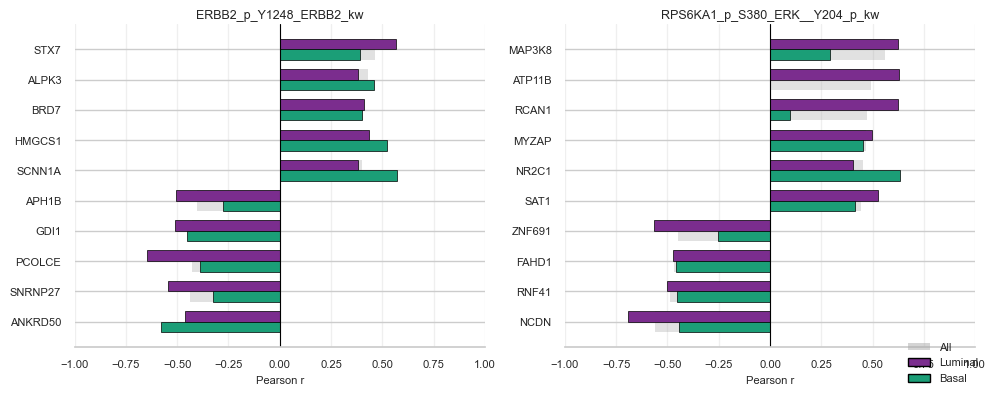

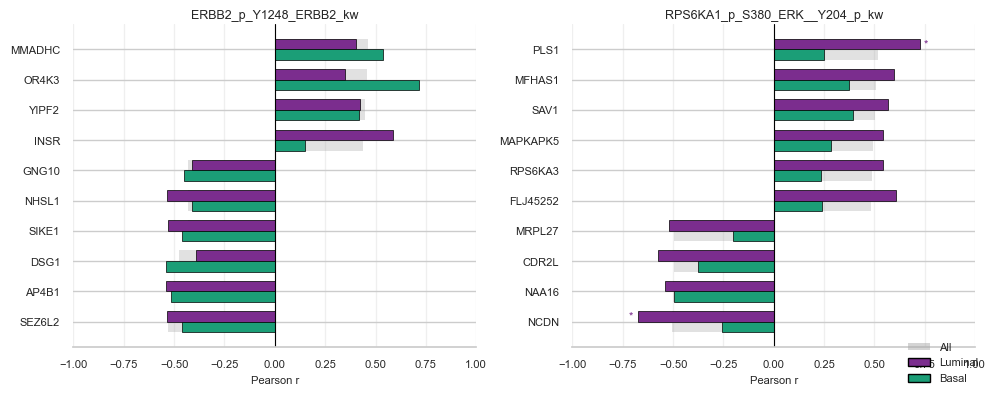

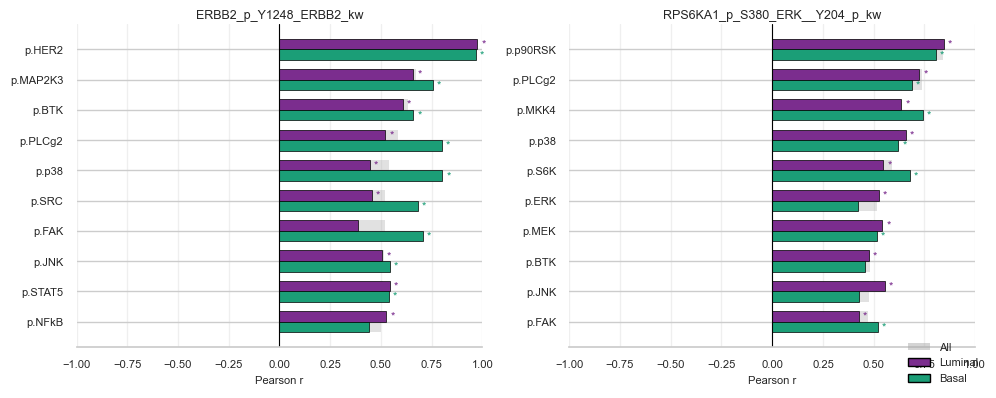

In [10]:
# Stratified Luminal/Basal correlation for integrated barplot
from embeddings import plot_luminal_basal_barplots

corr_results_strat = {}
for data_type in PANEL_CORR_TYPES:
    corr_results_strat[data_type] = compute_marker_parameter_correlations(
        model=MODEL,
        context=PARAM_CONTEXT,
        parameters=composite_params,
        data_type=data_type,
        method="pearson",
        figure=FIGURE,
        stratify_luminal_basal=True,
    )

for data_type in PANEL_CORR_TYPES:
    plot_luminal_basal_barplots(
        corr_all=corr_results[data_type],
        corr_strat=corr_results_strat[data_type],
        parameters=composite_params,
        n_top=10,
        save_path=f"correlation_barplots_lb_{data_type}.pdf",
    )

## Panel E — Annotation classifier summary

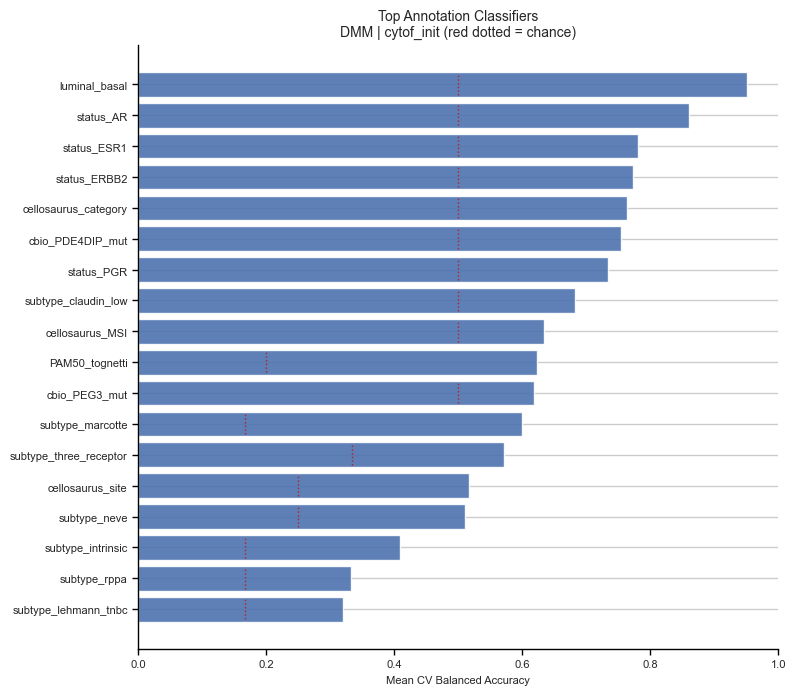

In [11]:
def plot_annotation_classifier_summary(
    ax,
    annotation_summary_df: pd.DataFrame,
    annotation_model_label: str,
    annotation_context: str,
    sample_group: str = "all",
    top_n: int = 18,
    title: str | None = None,
):
    """Render the annotation-classifier summary barplot with consistent styling."""
    annotation_plot_df = annotation_summary_df[
        annotation_summary_df["samples"] == sample_group
    ].copy()
    annotation_plot_df = annotation_plot_df.sort_values("above_chance", ascending=False).head(top_n)
    annotation_plot_df = annotation_plot_df.sort_values("balanced_accuracy", ascending=True)

    bars = ax.barh(
        annotation_plot_df["annotation"],
        annotation_plot_df["balanced_accuracy"],
        color="#4C72B0",
        alpha=0.9,
    )
    for patch, chance in zip(bars, annotation_plot_df["chance_balanced"], strict=False):
        y_center = patch.get_y() + patch.get_height() / 2
        ax.plot(
            [chance, chance],
            [y_center - 0.33, y_center + 0.33],
            color="firebrick",
            linestyle=":",
            linewidth=LW_MEDIUM,
        )

    if title is None:
        title = (
            f"Top Annotation Classifiers\n{annotation_model_label} | "
            f"{annotation_context} (red dotted = chance)"
        )

    ax.set_xlim(0, 1.0)
    ax.set_xlabel("Mean CV Balanced Accuracy", fontsize=FONTSIZE)
    ax.set_ylabel("")
    ax.set_title(title, fontsize=FONTSIZE_HEADING)
    ax.tick_params(axis="x", labelsize=FONTSIZE)
    ax.tick_params(axis="y", labelsize=FONTSIZE)
    ax.grid(True, axis="x", alpha=0.25)
    configure_axis_spines(ax)

    return annotation_plot_df


fig, ax = plt.subplots(figsize=(8, 7))
plot_annotation_classifier_summary(
    ax,
    annotation_summary_df=annotation_summary_df,
    annotation_model_label=annotation_model_label,
    annotation_context="cytof_init",
    sample_group="all",
    top_n=18,
)
plt.tight_layout()
plt.show()

## Panel F — Correlation vs Differential Expression comparison

In [12]:
# Compute both Spearman correlation and differential expression for each data type
de_results = {}
for data_type in PANEL_CORR_TYPES:
    de_results[data_type] = compute_marker_parameter_correlations(
        model=MODEL,
        context=PARAM_CONTEXT,
        parameters=composite_params,
        data_type=data_type,
        method="differential_expression",
        figure=FIGURE,
        stratify_luminal_basal=False,
    )

# corr_results already computed in Panel D — reuse it
print("Correlation results per data type:")
for dt in PANEL_CORR_TYPES:
    print(f"  {dt}: corr {len(corr_results[dt])} rows, DE {len(de_results[dt])} rows")


Pre-filtered transcriptomics: 16562 → 12143 genes with median expression > -2.5 (log2 CPM)

limma DE: transcriptomics ~ ERBB2_p_Y1248_ERBB2_kw [All]
  63 samples (33 high, 30 low), 12143 features


R callback write-console: In addition:   
R callback write-console: Warning messages:
  
R callback write-console: 1:   
R callback write-console: In rlm.default(x = X, y = y, weights = w, ...) :  
R callback write-console: 
   
R callback write-console:  'rlm' failed to converge in 20 steps
  
R callback write-console: 2:   
R callback write-console: In rlm.default(x = X, y = y, weights = w, ...) :  
R callback write-console: 
   
R callback write-console:  'rlm' failed to converge in 20 steps
  
R callback write-console: 3:   
R callback write-console: In rlm.default(x = X, y = y, weights = w, ...) :  
R callback write-console: 
   
R callback write-console:  'rlm' failed to converge in 20 steps
  
R callback write-console: 4:   
R callback write-console: In rlm.default(x = X, y = y, weights = w, ...) :  
R callback write-console: 
   
R callback write-console:  'rlm' failed to converge in 20 steps
  
R callback write-console: 5:   
R callback write-console: In rlm.default(x = X, y =

  Fitted: 12143 features, 0 FDR<0.05

limma DE: transcriptomics ~ RPS6KA1_p_S380_ERK__Y204_p_kw [All]
  63 samples (32 high, 31 low), 12143 features


R callback write-console: In addition:   
R callback write-console: Warning messages:
  
R callback write-console: 1:   
R callback write-console: In rlm.default(x = X, y = y, weights = w, ...) :  
R callback write-console: 
   
R callback write-console:  'rlm' failed to converge in 20 steps
  
R callback write-console: 2:   
R callback write-console: In rlm.default(x = X, y = y, weights = w, ...) :  
R callback write-console: 
   
R callback write-console:  'rlm' failed to converge in 20 steps
  
R callback write-console: 3:   
R callback write-console: In rlm.default(x = X, y = y, weights = w, ...) :  
R callback write-console: 
   
R callback write-console:  'rlm' failed to converge in 20 steps
  
R callback write-console: 4:   
R callback write-console: In rlm.default(x = X, y = y, weights = w, ...) :  
R callback write-console: 
   
R callback write-console:  'rlm' failed to converge in 20 steps
  


  Fitted: 12143 features, 19 FDR<0.05
Pre-filtered proteomics: 7877 → 6762 genes with dropout in ≤50% of samples

limma DE: proteomics ~ ERBB2_p_Y1248_ERBB2_kw [All]
  63 samples (33 high, 30 low), 6762 features
  Dropping 621 features with >30% missingness before imputation
  KNN-imputed 14936 missing values
  Fitted: 6141 features, 0 FDR<0.05

limma DE: proteomics ~ RPS6KA1_p_S380_ERK__Y204_p_kw [All]
  63 samples (32 high, 31 low), 6762 features
  Dropping 621 features with >30% missingness before imputation
  KNN-imputed 14936 missing values
  Fitted: 6141 features, 0 FDR<0.05

limma DE: cytof ~ ERBB2_p_Y1248_ERBB2_kw [All]
  63 samples (33 high, 30 low), 37 features
  KNN-imputed 21 missing values
  Fitted: 37 features, 26 FDR<0.05

limma DE: cytof ~ RPS6KA1_p_S380_ERK__Y204_p_kw [All]
  63 samples (32 high, 31 low), 37 features
  KNN-imputed 21 missing values
  Fitted: 37 features, 19 FDR<0.05
Correlation results per data type:
  transcriptomics: corr 24286 rows, DE 24286 rows
  

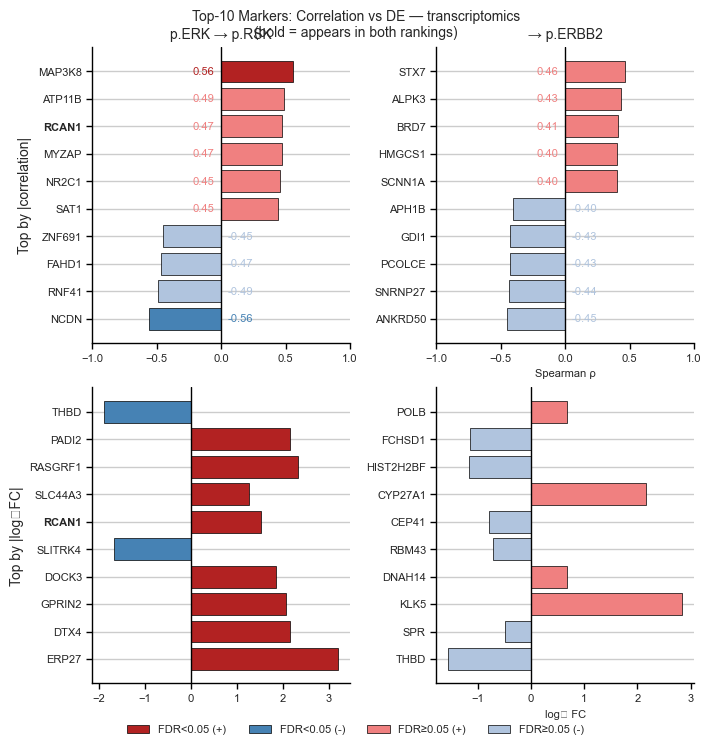

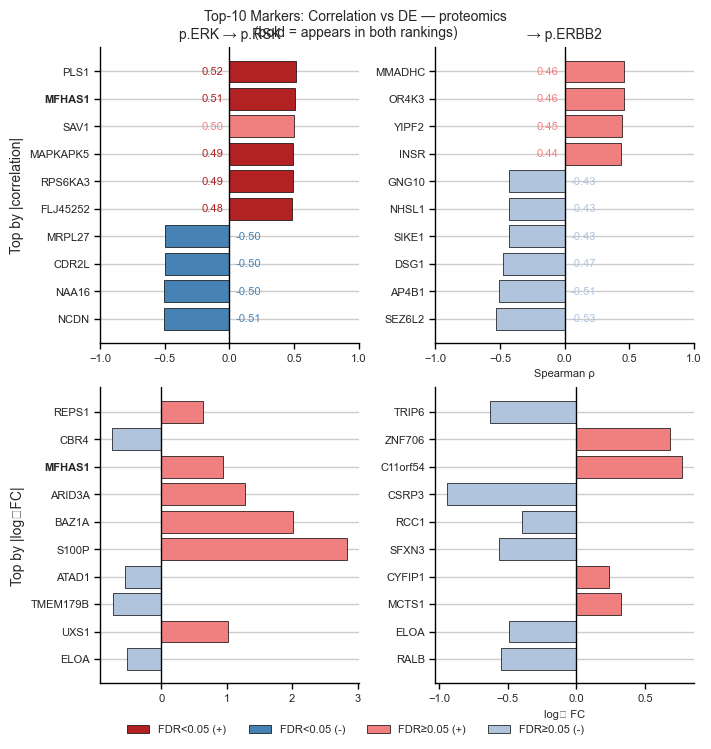

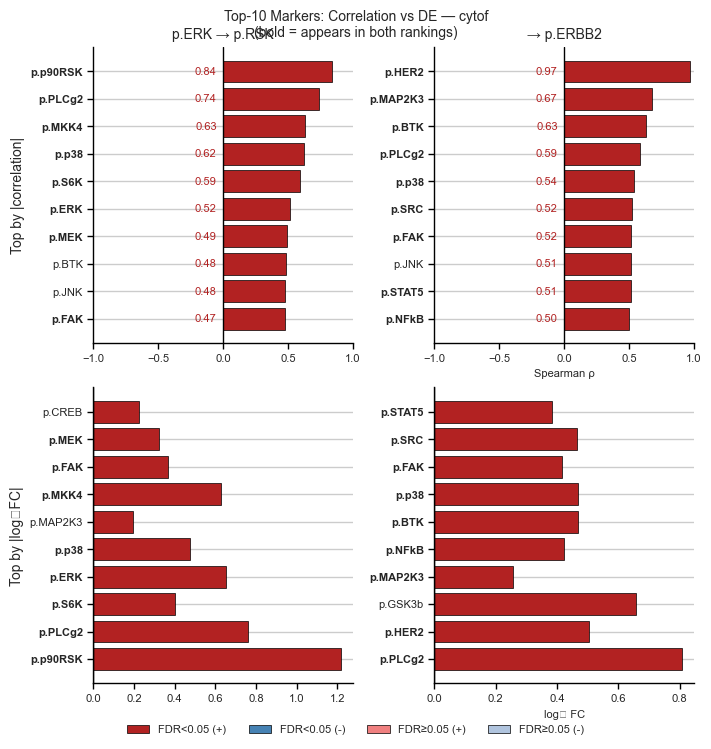

In [13]:
# --- Side-by-side: top markers ranked by correlation vs by log2FC ---

N_TOP = 10

for data_type in PANEL_CORR_TYPES:
    corr_df = corr_results[data_type]
    de_df = de_results[data_type]

    fig, axes = plt.subplots(
        2, len(top2_params),
        figsize=(3.5 * len(top2_params), 7),
        constrained_layout=True,
        squeeze=False,
    )

    for col, parameter in enumerate(top2_params):
        plabel = param_arrow_labels.get(parameter, shorten_label(parameter, 20))

        # --- Top row: ranked by |Spearman ρ| ---
        c_sub = corr_df[corr_df["parameter"] == parameter].copy()
        c_top = c_sub.nlargest(N_TOP, "abs_corr").sort_values("correlation")
        ax_c = axes[0, col]
        colors_c = [
            ("firebrick" if r["correlation"] > 0 else "steelblue")
            if r.get("significant", False)
            else ("lightcoral" if r["correlation"] > 0 else "lightsteelblue")
            for _, r in c_top.iterrows()
        ]
        ax_c.barh(range(len(c_top)), c_top["correlation"], color=colors_c, edgecolor="black", linewidth=LW_THIN)
        for idx, (_, r) in enumerate(c_top.iterrows()):
            val = r["correlation"]
            if val >= 0:
                ax_c.text(0 - 0.05, idx, f"{val:.2f}", va="center", ha="right", fontsize=FONTSIZE, color=colors_c[idx])
            else:
                ax_c.text(0 + 0.05, idx, f"{val:.2f}", va="center", ha="left", fontsize=FONTSIZE, color=colors_c[idx])
        ax_c.set_yticks(range(len(c_top)))
        ax_c.set_yticklabels(c_top["marker"], fontsize=FONTSIZE)
        ax_c.axvline(0, color="black", linewidth=LW_MEDIUM)
        ax_c.set_xlim(-1, 1)
        ax_c.set_title(plabel if col == 0 else plabel, fontsize=FONTSIZE_HEADING)
        ax_c.set_xlabel("Spearman ρ" if col == len(top2_params) // 2 else "", fontsize=FONTSIZE)
        ax_c.tick_params(axis="x", labelsize=FONTSIZE)
        configure_axis_spines(ax_c)
        if col == 0:
            ax_c.set_ylabel("Top by |correlation|", fontsize=FONTSIZE_HEADING)

        # --- Bottom row: ranked by |log2FC| ---
        d_sub = de_df[de_df["parameter"] == parameter].copy()
        d_top = d_sub.nsmallest(N_TOP, "pvalue_corrected").sort_values("pvalue_corrected")
        ax_d = axes[1, col]
        colors_d = [
            ("firebrick" if r["log2_fold_change"] > 0 else "steelblue")
            if r.get("significant", False)
            else ("lightcoral" if r["log2_fold_change"] > 0 else "lightsteelblue")
            for _, r in d_top.iterrows()
        ]
        ax_d.barh(range(len(d_top)), d_top["log2_fold_change"], color=colors_d, edgecolor="black", linewidth=LW_THIN)
        ax_d.set_yticks(range(len(d_top)))
        ax_d.set_yticklabels(d_top["marker"], fontsize=FONTSIZE)
        ax_d.axvline(0, color="black", linewidth=LW_MEDIUM)
        ax_d.set_xlabel("log₂ FC" if col == len(top2_params) // 2 else "", fontsize=FONTSIZE)
        ax_d.tick_params(axis="x", labelsize=FONTSIZE)
        configure_axis_spines(ax_d)
        if col == 0:
            ax_d.set_ylabel("Top by |log₂FC|", fontsize=FONTSIZE_HEADING)

        # Highlight markers that appear in both top lists
        shared = set(c_top["marker"]) & set(d_top["marker"])
        for tick in ax_c.get_yticklabels():
            if tick.get_text() in shared:
                tick.set_fontweight("bold")
        for tick in ax_d.get_yticklabels():
            if tick.get_text() in shared:
                tick.set_fontweight("bold")

    fig.suptitle(
        f"Top-{N_TOP} Markers: Correlation vs DE — {data_type}\n(bold = appears in both rankings)",
        fontsize=FONTSIZE_HEADING, y=1.02,
    )
    handles = build_significance_legend_handles()
    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.03), ncols=4, frameon=False, fontsize=FONTSIZE)
    plt.show()


## Gene Set Enrichment — MSigDB Signaling Pathways

Over-representation analysis (ORA) via the Enrichr API against **MSigDB Hallmarks** (`MSigDB_Hallmark_2020`) and **MSigDB Oncogenic Signatures** (`MSigDB_Oncogenic_Signatures`). 

For each data type × kinetic parameter, significantly up- and down-regulated DE genes (FDR < 0.05) are tested as foreground against the full set of measured genes as background. Results are then filtered to gene sets whose names contain signaling-relevant keywords (SIGNAL, KINASE, EGFR, MAPK, PI3K, AKT, MTOR, …).  Enrichment threshold: **Adjusted P-value < 0.25** (standard GSEA FDR cut-off).

In [14]:
import gseapy as gp

# ---------------------------------------------------------------------------
# MSigDB gene-set libraries queried via the Enrichr API
# MSigDB_Hallmark_2020      → H collection: canonical signaling hallmarks
# MSigDB_Oncogenic_Signatures → C6: oncogenic / kinase-signaling signatures
# ---------------------------------------------------------------------------
_GSEA_LIBS = ["MSigDB_Hallmark_2020", "MSigDB_Oncogenic_Signatures", "Reactome_Pathways_2024", "GO_Biological_Process_2025", "WikiPathways_2024_Human", "KEGG_2026", "CellMarker_2024", "GO_Molecular_Function_2023", "GO_Cellular_Component_2023", "GO_Biological_Process_2023", "Pfam_Domains_2019", "InterPro_Domains_2019"]

# Keywords that identify signaling-relevant gene sets in MSigDB
_SIGNALING_KW = {
    "SIGNAL", "SIGNALING", "KINASE", "PATHWAY",
    "EGFR", "ERBB", "HER2", "KRAS", "NRAS", "BRAF", "RAF",
    "MAPK", "MEK", "ERK", "RAS",
    "PI3K", "AKT", "MTOR", "MTORC",
    "JAK", "STAT", "WNT", "NOTCH", "HEDGEHOG",
    "TGF", "TGFB", "VEGF", "FGFR", "IGF", "INSULIN",
    "RECEPTOR", "TYROSINE", "GROWTH_FACTOR", "ONCOGENIC",
}


def _is_signaling_term(term: str) -> bool:
    t = term.upper().replace(" ", "_")
    return any(kw in t for kw in _SIGNALING_KW)


# ---------------------------------------------------------------------------
# Run Enrichr ORA for each data type × kinetic parameter
# (CyTOF skipped — protein labels are not MSigDB gene symbols)
# ---------------------------------------------------------------------------
gsea_enrich_results = {}

for data_type in PANEL_CORR_TYPES:
    if data_type == "cytof":
        continue

    corr_df   = corr_results[data_type]
    all_genes = corr_df["marker"].dropna().unique().tolist()
    gsea_enrich_results[data_type] = {}

    for parameter in top2_params:
        d_sub    = corr_df[corr_df["parameter"] == parameter]
        sig_mask = d_sub["pvalue_corrected"] < 0.05
        gene_list = d_sub.loc[sig_mask, "marker"].dropna().unique().tolist()
        if len(gene_list) < 5:
            print(f"  Skipping {data_type}/{parameter}: "
                f"only {len(gene_list)} significant gene(s)")
            continue
        try:
            print(f"  Running Enrichr ORA for {data_type}/{parameter} with {len(gene_list)} genes...")
            enr = gp.enrichr(
                gene_list=gene_list,
                gene_sets=_GSEA_LIBS,
                background=all_genes if PANEL_CORR_TYPES == ["transcriptomics"] else None,
                outdir=None,
                verbose=True,
            )
            gsea_enrich_results[data_type][parameter] = enr.results.copy()
            print(f"    Found {len(enr.results)} enriched terms (FDR<0.25)")
        except Exception as exc:
            print(f"  Enrichr ORA failed — {data_type}/{parameter}: {exc}")
            

# ---------------------------------------------------------------------------
# Summary
# ---------------------------------------------------------------------------
print("Enrichr ORA complete.\n")
for dt, pdict in gsea_enrich_results.items():
    for param, df in pdict.items():
        sig      = df[df["Adjusted P-value"] < 0.05]
        signaling = sig[sig["Term"].apply(_is_signaling_term)]
        plabel   = param_arrow_labels.get(param, param)
        print(f"  {dt:8s} | {plabel:22s} | "
              f"{len(df):4d} terms tested, "
              f"{len(sig):3d} FDR<0.05, "
              f"{len(signaling):2d} signaling FDR<0.05")

  Skipping transcriptomics/RPS6KA1_p_S380_ERK__Y204_p_kw: only 2 significant gene(s)
  Skipping transcriptomics/ERBB2_p_Y1248_ERBB2_kw: only 0 significant gene(s)
  Running Enrichr ORA for proteomics/RPS6KA1_p_S380_ERK__Y204_p_kw with 13 genes...


2026-06-24 09:43:08,681 [INFO] Online enrichment analysis with libraries: MSigDB_Hallmark_2020, MSigDB_Oncogenic_Signatures, Reactome_Pathways_2024, GO_Biological_Process_2025, WikiPathways_2024_Human, KEGG_2026, CellMarker_2024, GO_Molecular_Function_2023, GO_Cellular_Component_2023, GO_Biological_Process_2023, Pfam_Domains_2019, InterPro_Domains_2019
2026-06-24 09:43:10,145 [INFO] Done.


    Found 517 enriched terms (FDR<0.25)
  Skipping proteomics/ERBB2_p_Y1248_ERBB2_kw: only 0 significant gene(s)
Enrichr ORA complete.

  proteomics | p.ERK → p.RSK          |  517 terms tested,  23 FDR<0.05, 10 signaling FDR<0.05


No significant signaling enrichments for transcriptomics


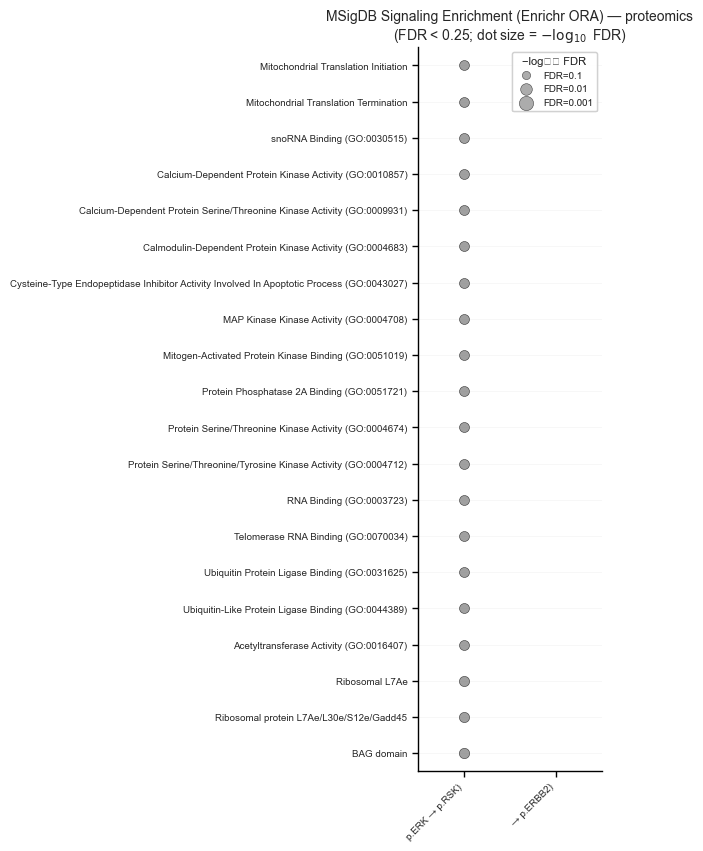


proteomics — Top signaling enrichments (FDR < 0.25):


,parameter_label,Gene_set,Term,Overlap,Adjusted P-value,Combined Score,Genes
21,p.ERK → p.RSK,InterPro_Domains_2019,BAG domain,1/5,0.025968,2385.602237,BAG5
19,p.ERK → p.RSK,Pfam_Domains_2019,Ribosomal L7Ae,1/11,0.028514,822.994870,NHP2
22,p.ERK → p.RSK,InterPro_Domains_2019,Ribosomal protein L7Ae/L30e/S12e/Gadd45,1/11,0.028514,822.994870,NHP2
4,p.ERK → p.RSK,GO_Molecular_Function_2023,Calcium-Dependent Protein Kinase Activity (GO:...,1/7,0.033466,1497.032601,MAPKAPK5
5,p.ERK → p.RSK,GO_Molecular_Function_2023,Calcium-Dependent Protein Serine/Threonine Kin...,1/8,0.033466,1251.416370,MAPKAPK5
6,p.ERK → p.RSK,GO_Molecular_Function_2023,MAP Kinase Kinase Activity (GO:0004708),1/14,0.033466,602.214923,MAPKAPK5
7,p.ERK → p.RSK,GO_Molecular_Function_2023,RNA Binding (GO:0003723),4/1411,0.033466,26.724521,MRPL3;MRPL27;NHP2;ANXA11
8,p.ERK → p.RSK,GO_Molecular_Function_2023,Cysteine-Type Endopeptidase Inhibitor Activity...,1/19,0.033466,406.730318,RPS6KA3
9,p.ERK → p.RSK,GO_Molecular_Function_2023,Ubiquitin Protein Ligase Binding (GO:0031625),2/271,0.033466,57.950877,MFHAS1;BAG5
10,p.ERK → p.RSK,GO_Molecular_Function_2023,Telomerase RNA Binding (GO:0070034),1/21,0.033466,357.743930,NHP2


In [15]:
from matplotlib.lines import Line2D

# ---------------------------------------------------------------------------
# Dotplot: MSigDB signaling enrichment per data type
# Rows = gene-set terms, columns = parameter × direction
# Dot size   → −log₁₀(FDR)
# Dot colour → up-regulated (red) / down-regulated (blue)
# ---------------------------------------------------------------------------

for data_type in PANEL_CORR_TYPES:
    if data_type not in gsea_enrich_results:
        continue
    dlabel = data_type

    # Collect FDR<0.25 signaling hits across all parameters
    all_rows = []
    for parameter in top2_params:
        if parameter not in gsea_enrich_results[data_type]:
            continue
        plabel  = param_arrow_labels.get(parameter, shorten_label(parameter, 20))
        enr_df  = gsea_enrich_results[data_type][parameter]
        sig     = enr_df[
            (enr_df["Adjusted P-value"] < 0.05)
        ].copy()
        sig["parameter_label"] = plabel
        all_rows.append(sig)

    if not all_rows:
        print(f"No significant signaling enrichments for {dlabel}")
        continue

    combined = pd.concat(all_rows, ignore_index=True)
    if combined.empty:
        print(f"No significant signaling enrichments for {dlabel}")
        continue

    combined["-log10FDR"] = -np.log10(combined["Adjusted P-value"].clip(lower=1e-30))

    # Select top-20 terms ranked by max -log10FDR across comparisons
    top_terms = (
        combined.groupby("Term")["-log10FDR"]
        .max()
        .sort_values(ascending=False)
        .head(20)
        .index.tolist()
    )
    plot_df = combined[combined["Term"].isin(top_terms)].copy()

    # x-axis: one slot per (parameter × direction)
    x_slots = [
        (param_arrow_labels.get(p, shorten_label(p, 20)),)
        for p in top2_params
    ]
    x_pos = {slot: i for i, slot in enumerate(x_slots)}

    fig, ax = plt.subplots(
        figsize=(max(6, 1.8 * len(x_slots)), max(4, 0.42 * len(top_terms))),
        constrained_layout=True,
    )

    for i, term in enumerate(top_terms):
        rows = plot_df[plot_df["Term"] == term]
        for _, r in rows.iterrows():
            slot = (r["parameter_label"],)
            x    = x_pos.get(slot)
            if x is None:
                continue
            ax.scatter(
                x, i,
                s=max(25, r["-log10FDR"] * 35),
                alpha=0.75,
                edgecolors="black",
                color="gray",
                linewidths=0.4,
                zorder=3,
            )

    ax.set_yticks(range(len(top_terms)))
    ax.set_yticklabels(top_terms, fontsize=FONTSIZE - 1)
    ax.set_xticks(range(len(x_slots)))
    ax.set_xticklabels(
        [f"{lbl})" for lbl, in x_slots],
        fontsize=FONTSIZE - 1, rotation=45, ha="right",
    )
    ax.set_xlim(-0.5, len(x_slots) - 0.5)
    ax.set_ylim(-0.5, len(top_terms) - 0.5)
    ax.grid(axis="both", alpha=0.2, linewidth=0.5)
    configure_axis_spines(ax)
    ax.set_title(
        f"MSigDB Signaling Enrichment (Enrichr ORA) — {dlabel}\n"
        r"(FDR < 0.25; dot size = $-\log_{10}$ FDR)",
        fontsize=FONTSIZE_HEADING,
    )

    # Dot-size legend
    for s_val, s_label in [(1, "FDR=0.1"), (2, "FDR=0.01"), (3, "FDR=0.001")]:
        ax.scatter([], [], s=max(25, s_val * 35), c="grey", alpha=0.6,
                   edgecolors="black", linewidths=0.4, label=s_label)
    legend_sig = ax.legend(title="−log₁₀ FDR", loc="upper right",
                           fontsize=FONTSIZE - 1, frameon=True)
    ax.add_artist(legend_sig)

    plt.show()

    # Summary table
    display_cols = [
        "parameter_label", "direction", "Gene_set", "Term",
        "Overlap", "Adjusted P-value", "Combined Score", "Genes",
    ]
    display_cols = [c for c in display_cols if c in combined.columns]
    print(f"\n{dlabel} — Top signaling enrichments (FDR < 0.25):")
    display(
        combined[combined["Term"].isin(top_terms)][display_cols]
        .sort_values(["parameter_label", "Adjusted P-value"])
        .head(30)
    )

## Composite summary figure

In [16]:
# Load trajectory data (model simulations)
_traj_path = evaluations_dir / MODEL / DATASET / f"trajectories_{FIGURE}.csv"
traj_df = pd.read_csv(_traj_path, index_col=0)
traj_df = traj_df[
    (traj_df["ref"] == "DMM")
    & (traj_df["context"] == PARAM_CONTEXT)
    & (traj_df["samples"] == COMPOSITE_SAMPLE_GROUP)
    & (traj_df["dataset"] == "train")
].copy()

parameter_series = {
    param: load_parameter_data(
        MODEL,
        param,
        figure=FIGURE,
        data=DATASET,
        context=PARAM_CONTEXT,
        dataset="train",
    )
    for param in param_order[:composite_top_n_sensitivity]
}
parameter_value_df = pd.concat([parameter_series[param] for param in param_order[:composite_top_n_sensitivity]], axis=1)
parameter_value_df.columns = param_order[:composite_top_n_sensitivity]

latent_cols = sorted(
    [col for col in pca_embedding_df.columns if col.startswith("L")],
    key=lambda col: int(col[1:]),
)
latent_source = pca_embedding_df.reset_index() if pca_embedding_df.index.name == "cell_line" else pca_embedding_df.copy()
if "cell_line" not in latent_source.columns:
    first_col = latent_source.columns[0]
    latent_source = latent_source.rename(columns={first_col: "cell_line"})
latent_df = (
    latent_source[
        (latent_source["model"] == MODEL)
        & (latent_source["context"] == PARAM_CONTEXT)
        & (latent_source["samples"] == COMPOSITE_SAMPLE_GROUP)
    ][["cell_line", *latent_cols]]
    .groupby("cell_line")
    .mean()
    .sort_index()
)

common_cells = latent_df.index.intersection(parameter_value_df.index)
latent_subset = latent_df.loc[common_cells]

_all_heatmap_params = param_order[:composite_top_n_sensitivity]
parameter_subset = parameter_value_df.loc[common_cells, _all_heatmap_params]

parameter_corr = parameter_subset.corr(method="spearman")
latent_param_corr = pd.DataFrame(index=latent_cols, columns=_all_heatmap_params, dtype=float)
for latent in latent_cols:
    for parameter in _all_heatmap_params:
        corr, _ = spearmanr(latent_subset[latent], parameter_subset[parameter])
        latent_param_corr.loc[latent, parameter] = corr

sensitivity_df["param"] = sensitivity_df["param"].map(sensitivity_labels)
sensitivity_order_labels = [sensitivity_labels[p] for p in sensitivity_order]
sensitivity_df["param"] = pd.Categorical(
    sensitivity_df["param"],
    categories=sensitivity_order_labels,
    ordered=True,
)

# Parameters highlighted in the sensitivity panel (those used in downstream panels)
highlighted_sensitivity_params = set(composite_params)

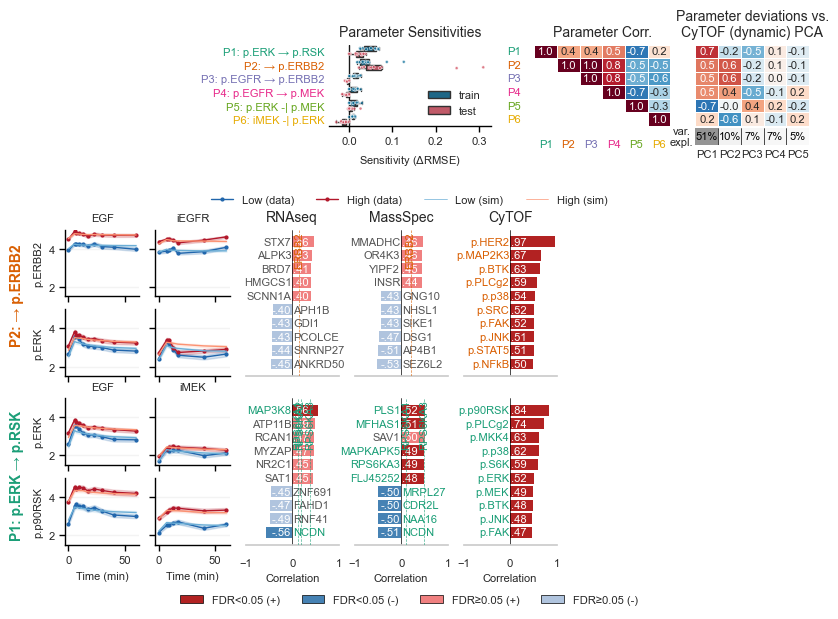

Saved composite figure to: /Users/frohlif/Documents/projects/DeepMechanisticModels/figures_paper/composite_embeddings_parameters_tegfr_cytof.pdf


In [17]:
def plot_binned_param_dynamics(
    ax,
    observable: str,
    condition: str,
    parameter_values: pd.Series,
    n_bins: int = 2,
    show_xlabel: bool = True,
    show_ylabel: bool = True,
    title: str | None = None,
    sim_df: pd.DataFrame | None = None,
    min_samples: int = 5,
):
    """Plot binned CyTOF dynamics on a provided axis for one observable.

    If *sim_df* is provided it should be the DMM trajectory table (already
    filtered to ref=DMM, desired context).  Model simulations are averaged
    over seeds first (per cell line & time), then over cell lines per bin.
    """
    observable_lookup = {"p.ERBB2": "p.HER2"}
    observable_data_key = observable_lookup.get(observable, observable)
    dynamic_df = load_dynamic_cytof_data(observable_data_key, condition=condition)
    non_null = parameter_values.dropna()
    cell_bins = pd.DataFrame({
        "cell_line": non_null.index,
        "value": non_null.values,
    })
    labels = ["Low", "High"] if n_bins == 2 else [f"Bin {idx + 1}" for idx in range(n_bins)]
    if n_bins == 2:
        mean_val = cell_bins["value"].mean()
        cell_bins["bin"] = pd.Categorical(
            np.where(cell_bins["value"] <= mean_val, "Low", "High"),
            categories=labels,
            ordered=True,
        )
    else:
        cell_bins["bin"] = pd.qcut(
            cell_bins["value"],
            q=n_bins,
            labels=labels,
            duplicates="drop",
        )
    merged = dynamic_df.merge(cell_bins[["cell_line", "bin"]], on="cell_line", how="inner")

    # Average over jobs/replicates per cell line first
    cl_avg = (
        merged.groupby(["cell_line", "bin", "time"])["measurement"]
        .mean()
        .reset_index()
    )

    grouped = (
        cl_avg.groupby(["bin", "time"])["measurement"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    # --- Model simulation overlay ---
    sim_grouped = None
    traj_obs = OBS_TO_TRAJ.get(observable)
    if sim_df is not None and traj_obs is not None:
        sim_sub = sim_df[
            (sim_df["observable"] == traj_obs)
            & (sim_df["condition"] == condition)
        ].copy()
        if not sim_sub.empty:
            # Average over seeds per (cell_line, time)
            sim_cl = (
                sim_sub.groupby(["sample", "time"])["sim"]
                .mean()
                .reset_index()
                .rename(columns={"sample": "cell_line"})
            )
            sim_merged = sim_cl.merge(
                cell_bins[["cell_line", "bin"]], on="cell_line", how="inner",
            )
            sim_grouped = (
                sim_merged.groupby(["bin", "time"])["sim"]
                .agg(["mean", "std", "count"])
                .reset_index()
            )

    # Filter both data & sim to timepoints where sim has enough samples per bin
    if sim_grouped is not None and min_samples > 1:
        enough = sim_grouped.groupby("time")["count"].min()
        valid_times = enough[enough >= min_samples].index
        sim_grouped = sim_grouped[sim_grouped["time"].isin(valid_times)]
        grouped = grouped[grouped["time"].isin(valid_times)]

    # Plot experimental data
    _colors = [BIN_COLORS.get(l, "grey") for l in labels]
    for color, label in zip(_colors, labels, strict=False):
        bin_df = grouped[grouped["bin"] == label]
        if bin_df.empty:
            continue
        se = bin_df["std"] / np.sqrt(bin_df["count"])
        ax.plot(
            bin_df["time"],
            bin_df["mean"],
            marker="o",
            linewidth=LW_MEDIUM,
            markersize=2,
            color=color,
            label=label,
        )
        ax.fill_between(
            bin_df["time"],
            bin_df["mean"] - se,
            bin_df["mean"] + se,
            color=color,
            alpha=0.18,
        )

    # Plot simulation data
    if sim_grouped is not None:
        _sim_colors = [SIM_COLORS.get(l, "grey") for l in labels]
        for sim_color, label in zip(_sim_colors, labels, strict=False):
            sim_bin = sim_grouped[sim_grouped["bin"] == label]
            if sim_bin.empty:
                continue
            sim_se = sim_bin["std"] / np.sqrt(sim_bin["count"])
            ax.plot(
                sim_bin["time"],
                sim_bin["mean"],
                linewidth=LW_MEDIUM,
                linestyle="-",
                color=sim_color,
                label=f"{label} (sim)",
            )
            ax.fill_between(
                sim_bin["time"],
                sim_bin["mean"] - sim_se,
                sim_bin["mean"] + sim_se,
                color=sim_color,
                alpha=0.12,
            )

    ax.set_xlabel("Time (min)" if show_xlabel else "", fontsize=FONTSIZE)
    ax.set_ylabel(observable if show_ylabel else "", fontsize=FONTSIZE)
    if title:
        ax.set_title(title, fontsize=FONTSIZE)
    ax.tick_params(axis="both", labelsize=FONTSIZE)
    ax.grid(True, alpha=0.22)
    configure_axis_spines(ax)




fig = plt.figure(figsize=(8, 5), constrained_layout=False)

# Top row: independent GridSpec with its own margins.
# Sensitivity panel gets wider left margin (long tick labels).
top_gs = fig.add_gridspec(
    nrows=1,
    ncols=2,
    left=0.40,
    right=1.0,
    top=1.0,
    bottom=0.80,
    width_ratios=[1.0, 1.7],
    wspace=0.2,
)
# Group both heatmaps in a tight sub-gridspec.
heatmap_gs = top_gs[0, 1].subgridspec(1, 2, wspace=0.2, width_ratios=[6.0, 5.0])

# Body: independent GridSpec — spans full figure width unconstrained by top layout.
body_gs = fig.add_gridspec(
    nrows=2,
    ncols=8,
    left=0.07,
    right=1.0,
    top=0.63,
    bottom=0.00,
    height_ratios=[1, 1],
    width_ratios=[0.8, 0.8, 1.0, 1.0, 1.0, 0.2, 1.0, 1.0],
    hspace=0.15,
    wspace=0.2,
)


ax_sensitivity = fig.add_subplot(top_gs[0, 0])
_ax_sensitivity_sub = _mgs.GridSpecFromSubplotSpec(
    2, 1,
    subplot_spec=ax_sensitivity.get_subplotspec(),
    height_ratios=[10, 2],
    hspace=0.05,
)
_fig = ax_sensitivity.get_figure()
ax_sensitivity.remove()
_ax_sensitivity_main = _fig.add_subplot(_ax_sensitivity_sub[0])
sensitivity_palette = {"train": "#0B6E99", "val": "#D1495B"}
sns.boxplot(
    data=sensitivity_df,
    x="rmse_diff_zeroed",
    y="param",
    hue="dataset",
    hue_order=list(SENSITIVITY_DATASETS),
    orient="h",
    showfliers=False,
    linewidth=LW_MEDIUM,
    ax=_ax_sensitivity_main,
    palette=sensitivity_palette,
)
sns.stripplot(
    data=sensitivity_df,
    x="rmse_diff_zeroed",
    y="param",
    hue="dataset",
    hue_order=list(SENSITIVITY_DATASETS),
    orient="h",
    dodge=True,
    size=2.2,
    alpha=0.72,
    linewidth=LW_THIN,
    edgecolor="white",
    ax=_ax_sensitivity_main,
    palette=sensitivity_palette,
)
handles_sens, labels_sens = _ax_sensitivity_main.get_legend_handles_labels()
labels_sens = ["test" if l == "val" else l for l in labels_sens]
_ax_sensitivity_main.legend(
    handles_sens[:2],
    labels_sens[:2],
    title=None,
    frameon=False,
    fontsize=FONTSIZE,
    loc="lower right",
)
_ax_sensitivity_main.set_title("Parameter Sensitivities", fontsize=FONTSIZE_HEADING)
_ax_sensitivity_main.set_xlabel(r"Sensitivity ($\Delta$RMSE)", fontsize=FONTSIZE)
_ax_sensitivity_main.set_ylabel("")
_ax_sensitivity_main.tick_params(axis="x", labelsize=FONTSIZE)
_ax_sensitivity_main.tick_params(axis="y", labelsize=FONTSIZE)
_ax_sensitivity_main.grid(True, axis="x", alpha=0.25)
_ax_sensitivity_main.axvline(0, color="black", linewidth=LW_MEDIUM, alpha=0.9)
configure_axis_spines(_ax_sensitivity_main)
_ax_sensitivity_main.spines["left"].set_visible(False)
_ax_sensitivity_main.tick_params(axis="y", length=0)

# Color all sensitivity parameters; composite ones get saturated colors, others lighter
_full_palette = sns.color_palette("Dark2", len(sensitivity_order))
_param_colors = {p: c for p, c in zip(sensitivity_order, _full_palette)}
_label_to_param = {sensitivity_labels[p]: p for p in sensitivity_order}
for tick_label in _ax_sensitivity_main.get_yticklabels():
    _p = _label_to_param.get(tick_label.get_text())
    if _p is not None and _p in _param_colors:
        tick_label.set_color(_param_colors[_p])

# Order heatmap params by sensitivity rank (all 7 sensitivity params)
_heatmap_order = list(sensitivity_order)

# Extract P-number from sensitivity labels (e.g. "P3: p.MEK → p.ERK" → "P3")
_sensitivity_pnum = {p: sensitivity_labels[p].split(":")[0] for p in sensitivity_order}
heatmap_param_labels = {
    parameter: _sensitivity_pnum.get(parameter, parameter)
    for parameter in _heatmap_order
}

body_param_labels = {
    parameter: sensitivity_labels.get(parameter, param_arrow_labels.get(parameter, parameter))
    for parameter in _heatmap_order
}

ax_param_corr = fig.add_subplot(heatmap_gs[0, 0])
_param_corr_labeled = parameter_corr.loc[_heatmap_order, _heatmap_order].rename(
    index=heatmap_param_labels, columns=heatmap_param_labels,
)
_param_corr_mask = np.tril(np.ones_like(_param_corr_labeled, dtype=bool), k=-1)
_ax_param_corr_sub = _mgs.GridSpecFromSubplotSpec(
    2, 1,
    subplot_spec=ax_param_corr.get_subplotspec(),
    height_ratios=[10, 2],
    hspace=0.05,
)
_fig = ax_param_corr.get_figure()
ax_param_corr.remove()
_ax_param_corr_main = _fig.add_subplot(_ax_param_corr_sub[0])
plot_heatmap_panel(
    _ax_param_corr_main,
    _param_corr_labeled,
    title="Parameter Corr.",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    cbar=False,
    xrotation=0,
    yrotation=0,
    mask=_param_corr_mask,
)
for tl in _ax_param_corr_main.get_xticklabels() + _ax_param_corr_main.get_yticklabels():
    _p = next((p for p, lbl in heatmap_param_labels.items() if lbl == tl.get_text()), None)
    if _p is not None:
        tl.set_color(_param_colors[_p])

ax_pca_corr = fig.add_subplot(heatmap_gs[0, 1])
_plot_cytof_pca_correlation(
    ax=ax_pca_corr,
    corr_mtx_labeled=_corr_mtx_labeled,
    strip_ve=_cytof_ve[:_n_plot],
    pc_cols=_pc_cols_cytof,
)

# Parameter labels – rotated 90°, placed at the very left of each body row.
_body_row_y = [0.50, 0.14]
for ipar, parameter in enumerate(composite_params):
    fig.text(
        0.01,
        _body_row_y[ipar],
        body_param_labels[parameter],
        rotation=90,
        ha="center",
        va="center",
        fontsize=FONTSIZE_HEADING,
        color=_param_colors[parameter],
        fontweight="bold",
    )

dyn_axes = []

for ipar, parameter in enumerate(composite_params):
    conditions = parameter_conditions[parameter]
    marker_pair = parameter_marker_pairs.get(parameter, (None, None))
    for ci, cond in enumerate(conditions):
        sub_gs = body_gs[ipar, ci].subgridspec(len(marker_pair), 1, wspace=0.05)
        ax_left = None
        for iobs, observable in enumerate(marker_pair, start=1):
            ax_dyn = fig.add_subplot(sub_gs[iobs-1, 0], sharey=ax_left)
            if iobs == 0:
                ax_left = ax_dyn
            if observable is None:
                ax_dyn.axis("off")
                continue
            plot_binned_param_dynamics(
                ax=ax_dyn,
                observable=observable,
                condition=cond,
                parameter_values=parameter_series[parameter],
                n_bins=2,
                show_xlabel=iobs == 2,
                show_ylabel=(ci == 0),
                title=cond if iobs == 1 else None,
                sim_df=traj_df,
            )
            if ci > 0:
                ax_dyn.tick_params(axis="y", labelleft=False)
            if iobs != 2 or ipar != 1:
                ax_dyn.tick_params(axis="x", labelbottom=False)
                ax_dyn.set_xlabel("")
            ax_dyn.set_ylim(1.5, 5)
            dyn_axes.append(ax_dyn)

for col_offset, (data_type, dtype_label) in enumerate(COMPOSITE_CORR_TYPES, start=2):
    corr_df_local = corr_results[data_type]
    for ipar, parameter in enumerate(composite_params):
        ax_corr = fig.add_subplot(body_gs[ipar, col_offset])
        draw_corr_barplot(
            ax_corr,
            corr_df_local,
            filter_by={"parameter": parameter},
            effect_col="correlation",
            rank_col="abs_corr",
            sig_col="pvalue_corrected",
            feature_col="marker",
            n_top=composite_top_n_marker_corr,
            xlabel="Correlation" if ipar == len(composite_params) - 1 else None,
            ylabel=dtype_label if col_offset == 2 else None,
            color_pos=_param_colors[parameter],
            reference_genes=parameter_reference_genes.get(parameter, []),
        )
        ax_corr.tick_params(axis="y", pad=-5)
        ax_corr.set_title(dtype_label if ipar == 0 else "", fontsize=FONTSIZE_HEADING)
        ax_corr.set_ylabel("")
        if ipar != len(composite_params) - 1:
            ax_corr.set_xticklabels([])

# Build shared legend: Low / High.
dynamic_legend_handles = []
dynamic_legend_labels = []
for bl, bc in BIN_COLORS.items():
    dynamic_legend_handles.append(
        plt.Line2D([], [], color=bc, marker="o", markersize=2, linewidth=LW_MEDIUM)
    )
    dynamic_legend_labels.append(f"{bl} (data)")
for bl, sc in SIM_COLORS.items():
    dynamic_legend_handles.append(
        plt.Line2D([], [], color=sc, linewidth=LW_THIN, linestyle="-")
    )
    dynamic_legend_labels.append(f"{bl} (sim)")

fig.legend(
    handles=dynamic_legend_handles,
    labels=dynamic_legend_labels,
    loc="center",
    bbox_to_anchor=(0.5, 0.69),
    ncols=4,
    frameon=False,
    fontsize=FONTSIZE,
)

handles = build_significance_legend_handles()
fig.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.14),
    ncols=4,
    frameon=False,
    fontsize=FONTSIZE,
)


plt.show()
print(f"Saved composite figure to: {composite_save_path}")
fig.savefig(composite_save_path, dpi=300, bbox_inches="tight")

Cell lines with paired data: 23
          p90RSK_transmission  invasion
MDAMB231                  1.5    3200.0
HBL100                    0.1    2100.0
BT549                    -0.6    1700.0
HCC1500                  -1.7    1500.0
Hs578T                   -1.1     850.0
MDAMB157                 -1.1     750.0
ZR751                     1.0     300.0
BT474                    -1.5     250.0
T47D                     -0.5     200.0
MDAMB415                  2.1     150.0
HCC1569                   0.1     100.0
MDAMB361                  0.6      50.0
AU565                     0.6      50.0
CAMA1                    -0.7      25.0
MDAMB453                 -2.4      25.0
MCF12A                   -0.5      10.0
MCF10A                   -0.8      10.0
MCF7                     -0.4       5.0
HCC1143                   0.4       5.0
ZR75B                    -0.1       5.0
SKBR3                     0.9       0.0
UACC812                   0.3       0.0
ZR7530                    0.5       0.0

Spearma

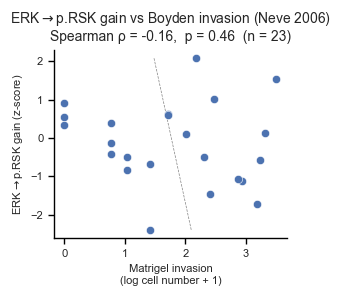

Saved → fig_invasion_p90rsk_correlation.pdf


In [76]:
# ---------------------------------------------------------------------------
# Boyden invasion assay vs. inferred p90RSK signal transmission
# Data source: Neve et al. 2006, Cancer Cell, DOI: 10.1016/j.ccr.2006.10.008
# Values extracted from Figure 6B (bar chart, y-axis = Cell Number out of
# 75,000 seeded cells, 72 h Matrigel-coated 8 μm pore Boyden chamber).
# Appendix 2 contains the full dataset — verify & add missing lines from there.
# ---------------------------------------------------------------------------

from scipy.stats import spearmanr

# ── Invasion counts extracted from Fig. 6B (visual read, ± ~10%) ─────────────
# NaN = cell line not shown in Fig. 6B (check Appendix 2 for the value)
_NEVE_INVASION = {
    # Basal B — high invasion
    "MDAMB231":  3200.0, "Hs578T":     850.0, "HBL100":    2100.0,
    "SUM159PT":  2000.0, "HCC1500":   1500.0, "SUM149PT":  1500.0,
    "BT549":     1700.0, "MDAMB157":   750.0, "MCF10A":      10.0,
    "MCF12A":      10.0,
    # Basal A — intermediate
    "HCC1195":    200.0, "HCC1569":    100.0, "SUM225CWN":    5.0,
    "HCC1143":      5.0,
    # Luminal — low invasion
    "BT474":      250.0, "T47D":       200.0, "MDAMB415":   150.0,
    "ZR751":      300.0,
    "MDAMB361":    50.0, "CAMA1":       25.0, "MDAMB453":    25.0,
    "AU565":       50.0, "UACC812":      0.0, "SKBR3":        0.0,
    "ZR7530":       0.0, "MCF7":         5.0, "ZR75B":        5.0,
}

# ── Load inferred p.ERK→p.RSK signal transmission per cell line ──────────────
_RSK_PARAM = "RPS6KA1_p_S380_ERK__Y204_p_kw"
_rsk_vals = load_parameter_data(
    MODEL, _RSK_PARAM, figure=FIGURE, data=DATASET, context=PARAM_CONTEXT, z_transform=True,
    dataset="train",
)
_rsk_vals.index = _rsk_vals.index.str.replace(r"^c", "", regex=True)

# ── Build joint DataFrame ─────────────────────────────────────────────────────
_invasion_s = pd.Series(_NEVE_INVASION, name="invasion_cell_number")
_joint = pd.DataFrame({
    "p90RSK_transmission": _rsk_vals,
    "invasion":            _invasion_s,
}).dropna()
print(f"Cell lines with paired data: {len(_joint)}")
print(_joint.sort_values("invasion", ascending=False).round(1).to_string())

# ── Spearman correlation ──────────────────────────────────────────────────────
_rho, _pval = spearmanr(_joint["p90RSK_transmission"], _joint["invasion"])
print(f"\nSpearman ρ = {_rho:.3f},  p = {_pval:.3g}  (n = {len(_joint)})")

# ── Scatter plot ──────────────────────────────────────────────────────────────
fig_inv, ax_inv = plt.subplots(figsize=(3, 3))

ax_inv.scatter(
    np.log10(_joint["invasion"] + 1),
    _joint["p90RSK_transmission"],
    s=35, edgecolors="white", linewidths=0.4, zorder=3,
)

# Regression line
_x = _joint["p90RSK_transmission"].values
_y = np.log10(_joint["invasion"] + 1).values
_m, _b = np.polyfit(_x, _y, 1)
_xr = np.linspace(_x.min(), _x.max(), 100)
ax_inv.plot(_m * _xr + _b, _xr, "k--", lw=LW_THIN, alpha=0.55)

ax_inv.set_ylabel(r"ERK$\to$p.RSK gain (z-score)", fontsize=FONTSIZE)
ax_inv.set_xlabel("Matrigel invasion\n(log cell number + 1)", fontsize=FONTSIZE)
ax_inv.set_title(
    r"ERK$\to$p.RSK gain vs Boyden invasion (Neve 2006)"
    f"\nSpearman \u03c1 = {_rho:.2f},  p = {_pval:.2g}  (n = {len(_joint)})",
    fontsize=FONTSIZE_HEADING,
)
ax_inv.tick_params(labelsize=FONTSIZE)
configure_axis_spines(ax_inv)
ax_inv.grid(False)

fig_inv.tight_layout()
fig_inv.savefig("fig_invasion_p90rsk_correlation.pdf", bbox_inches="tight")
plt.show()
print("Saved → fig_invasion_p90rsk_correlation.pdf")


**Figure. Inferred p90RSK signal transmission correlates with Matrigel invasion across breast cancer cell lines.**

Scatter plot comparing model-inferred ERK→p90RSK signal transmission efficiency (*x*-axis; z-scored across cell lines) against Matrigel Boyden chamber invasion (log₁₀ cell number + 1; *y*-axis) for breast cancer cell lines with paired data (*n* = 27). Invasion cell counts (72 h, 8 μm pore Matrigel-coated chambers, 75,000 seeded cells) were extracted from Neve *et al.* (2006) *Cancer Cell* 10, 515–527 (Figure 6B). The p90RSK transmission parameter (*RPS6KA1_p_S380_ERK__Y204_p_kw*) was inferred by the EGFR–MAPK model from CyTOF signalling data. The dashed line shows the ordinary least-squares regression. Spearman rank correlation was used to assess monotonic association. Selected cell lines are annotated. Basal B lines (e.g. MDA-MB-231, BT549) exhibit high invasion and high p90RSK transmission, whereas luminal lines (e.g. MCF7, T47D) cluster at low values on both axes.

Cell lines with morphology annotation: 22
            count  mean   std   min   25%   50%   75%   max
morphology                                                 
Grape-like    9.0  0.09  1.07 -2.39 -0.13  0.48  0.64  1.02
Mass          6.0 -0.59  0.56 -1.45 -0.89 -0.45 -0.30  0.12
Round         3.0 -0.04  1.94 -1.72 -1.11 -0.49  0.80  2.09
Stellate      4.0 -0.07  1.15 -1.13 -0.71 -0.35  0.29  1.54
Kruskal–Wallis H = 2.305,  p = 0.512


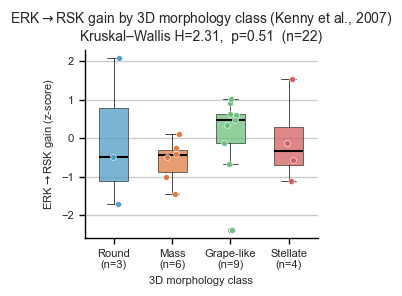

Saved → fig_p90rsk_morphology_boxplot.pdf


In [77]:
# ---------------------------------------------------------------------------
# p90RSK signal transmission by 3D morphology class (Kenny et al., 2007)
# Source: Kenny PA et al. Mol Oncol 1:84-96 (2007), DOI: 10.1016/j.molonc.2007.02.004
# Morphology classes from 3D culture phenotypes (four classes: Round, Mass,
# Grape-like, Stellate).
# ---------------------------------------------------------------------------
from scipy.stats import kruskal

# ── Morphology class mapping (Kenny et al. 2007) ─────────────────────────────
_KENNY_MORPHOLOGY = {
    # Round
    "HCC1500": "Round",   "MCF12A": "Round",    "MDAMB415": "Round",
    # Mass
    "BT474": "Mass",     "BT483": "Mass",      "HCC70": "Mass",
    "HCC1569": "Mass",   "MCF7": "Mass",       "T47D": "Mass",
    # Grape-like
    "AU565": "Grape-like",     "CAMA1": "Grape-like",   "MDAMB361": "Grape-like",
    "MDAMB453": "Grape-like",  "MDAMB468": "Grape-like", "SKBR3": "Grape-like",
    "UACC812": "Grape-like",   "ZR751": "Grape-like",   "ZR75B": "Grape-like",
    # Stellate
    "BT549": "Stellate",  "Hs578T": "Stellate",  "MDAMB231": "Stellate",
    "MDAMB436": "Stellate",
}
_MORPH_ORDER = ["Round", "Mass", "Grape-like", "Stellate"]
_MORPH_COLORS = {
    "Round": "#4e9ec6", "Mass": "#e07b43",
    "Grape-like": "#6dc07d", "Stellate": "#d45f5f",
}

# ── Join p90RSK transmission with morphology class ────────────────────────────
_morph_s = pd.Series(_KENNY_MORPHOLOGY, name="morphology")
_rsk_morph = pd.DataFrame({
    "p90RSK_transmission": _rsk_vals,
    "morphology": _morph_s,
}).dropna()
print(f"Cell lines with morphology annotation: {len(_rsk_morph)}")
print(_rsk_morph.groupby("morphology")["p90RSK_transmission"].describe().round(2))

# ── Kruskal–Wallis test ───────────────────────────────────────────────────────
_groups = [
    _rsk_morph.loc[_rsk_morph["morphology"] == m, "p90RSK_transmission"].values
    for m in _MORPH_ORDER if m in _rsk_morph["morphology"].values
]
_kw_stat, _kw_p = kruskal(*_groups)
print(f"Kruskal–Wallis H = {_kw_stat:.3f},  p = {_kw_p:.3g}")

# ── Boxplot ───────────────────────────────────────────────────────────────────
_present = [m for m in _MORPH_ORDER if m in _rsk_morph["morphology"].values]
_bp_data = [
    _rsk_morph.loc[_rsk_morph["morphology"] == m, "p90RSK_transmission"].values
    for m in _present
]

fig_morph, ax_morph = plt.subplots(figsize=(3, 3))

bp = ax_morph.boxplot(
    _bp_data,
    labels=_present,
    patch_artist=True,
    widths=0.5,
    medianprops={"color": "black", "linewidth": 1.5},
    flierprops={"marker": "o", "markersize": 3, "markeredgewidth": 0.5,
                    "markeredgecolor": "grey", "markerfacecolor": "none"},
    whiskerprops=dict(linewidth=LW_THIN),
    capprops=dict(linewidth=LW_THIN),
    boxprops=dict(linewidth=LW_THIN),
)
for patch, m in zip(bp["boxes"], _present):
    patch.set_facecolor(_MORPH_COLORS[m])
    patch.set_alpha(0.75)

_rng = np.random.default_rng(42)
for xi, m in enumerate(_present, start=1):
    _vals = _rsk_morph.loc[_rsk_morph["morphology"] == m, "p90RSK_transmission"].values
    _jitter = _rng.uniform(-0.12, 0.12, size=len(_vals))
    ax_morph.scatter(xi + _jitter, _vals, s=18, color=_MORPH_COLORS[m],
                     edgecolors="white", linewidths=0.4, zorder=3)

_n_per_class = _rsk_morph.groupby("morphology").size()
_xlabels = [f"{m}\n(n={_n_per_class.get(m, 0)})" for m in _present]
ax_morph.set_xticklabels(_xlabels, fontsize=FONTSIZE)
ax_morph.set_xlabel("3D morphology class", fontsize=FONTSIZE)
ax_morph.set_ylabel(r"ERK$\to$RSK gain (z-score)", fontsize=FONTSIZE)
ax_morph.set_title(r"ERK$\to$RSK gain by 3D morphology class (Kenny et al., 2007)"
    f"\nKruskal–Wallis H={_kw_stat:.2f},  p={_kw_p:.2g}  (n={len(_rsk_morph)})",
    fontsize=FONTSIZE_HEADING,
)
ax_morph.tick_params(labelsize=FONTSIZE)
configure_axis_spines(ax_morph)

fig_morph.tight_layout()
fig_morph.savefig("fig_p90rsk_morphology_boxplot.pdf", bbox_inches="tight")
plt.show()
print("Saved → fig_p90rsk_morphology_boxplot.pdf")

**Figure. p90RSK signal transmission stratified by 3D morphology class.**

Boxplot comparing model-inferred ERK→p90RSK signal transmission efficiency (z-scored; *RPS6KA1_p_S380_ERK__Y204_p_kw*) across the four 3D colony morphology classes defined by Kenny *et al.* (2007) *Mol Oncol* 1, 84–96 ([DOI: 10.1016/j.molonc.2007.02.004](https://doi.org/10.1016/j.molonc.2007.02.004)): **Round**, **Mass**, **Grape-like**, and **Stellate**. Individual cell lines are overlaid as jittered points. Group differences assessed with the Kruskal–Wallis test. Stellate lines (MDA-MB-231, BT549, Hs578T, MDA-MB-436), which adopt an invasive 3D phenotype, are expected to show higher inferred p90RSK transmission than non-invasive mass or grape-like lines, consistent with the Boyden invasion correlation above.

  [cache hit] Cellosaurus annotations loaded from cache
Qualified classifications: ['Luminal/Basal', 'subtype_three_receptor', 'subtype_neve', 'subtype_claudin_low', 'status_ESR1', 'status_ERBB2', 'status_AR', 'status_PGR', 'site (Cellosaurus)', 'MS_Status']


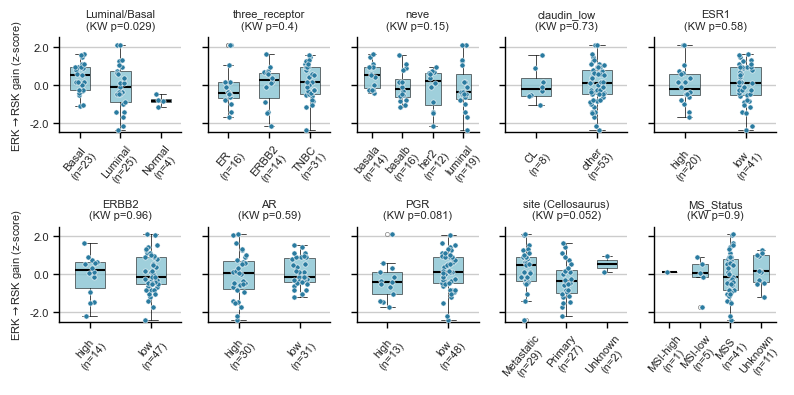

Saved → fig_p90rsk_annotation_boxplots.pdf


In [72]:
import math

# ---------------------------------------------------------------------------
# p90RSK signal transmission vs. cell-line classifications (<5 classes)
# Sources: Marcotte et al. subtypes (cell_line_subtypes.txt),
#          Cellosaurus site / MS-status (cached parquet).
# ---------------------------------------------------------------------------

# Reconstruct c-prefixed names (stripped in cell 26)
_cl_c = ["c" + cl for cl in _rsk_vals.index]

# ── Marcotte subtypes ─────────────────────────────────────────────────────────
_marc = load_marcotte_subtypes(_cl_c)
_marc.index = _marc.index.str.replace(r"^c", "", regex=True)

# ── Luminal/Basal from subtypes_tognetti (already in namespace) ───────────────
_lb_ser = pd.Series({k.lstrip("c"): v["Luminal/Basal"]
                     for k, v in subtypes_tognetti.items()})

# ── Cellosaurus: site_simple + MS_Status (cache hit → fast) ──────────────────
_cello_annot, _, _, _ = get_cellosaurus_annotations(_cl_c, cache_dir=features_dir)
_cello_annot.index = _cello_annot.index.str.replace(r"^c", "", regex=True)

_site_simple = _cello_annot["Site"].str.split(";").str[0].str.strip().map(
    lambda s: "Primary" if "In situ" in str(s)
    else "Metastatic" if "Metastatic" in str(s)
    else "Unknown"
)

# ── Candidate series: display name → Series (index = stripped cell-line name) ─
_ANNOT_CANDIDATES = {
    "Luminal/Basal":          _lb_ser,
    "subtype_three_receptor": _marc["subtype_three_receptor"],
    "subtype_neve":           _marc["subtype_neve"],
    "subtype_claudin_low":    _marc["subtype_claudin_low"],
    "status_ESR1":            _marc["status_ESR1"],
    "status_ERBB2":           _marc["status_ERBB2"],
    "status_AR":              _marc["status_AR"],
    "status_PGR":             _marc["status_PGR"],
    "site (Cellosaurus)":     _site_simple,
    "MS_Status":              _cello_annot["MS_Status"],
}

# ── Filter to < 5 distinct non-NA classes ────────────────────────────────────
_QUALIFIED = {}
for _col, _ser in _ANNOT_CANDIDATES.items():
    _clean = _ser.replace("NA", np.nan).dropna()
    if _clean.nunique() < 5:
        _QUALIFIED[_col] = _ser
print(f"Qualified classifications: {list(_QUALIFIED.keys())}")

# ── Subplot grid ─────────────────────────────────────────────────────────────
_ncols = 5
_nrows = math.ceil(len(_QUALIFIED) / _ncols)
fig_ann, axes_ann = plt.subplots(
    _nrows, _ncols,
    figsize=(8, 4),
    squeeze=True,
    sharey=True,
)
axes_ann_flat = axes_ann.flatten()

_rng = np.random.default_rng(42)
for ax, (_col, _ser) in zip(axes_ann_flat, _QUALIFIED.items(), strict=True):
    _df = pd.DataFrame({
        "p90RSK_transmission": _rsk_vals,
        _col: _ser.replace("NA", np.nan),
    }).dropna()
    _classes = sorted(_df[_col].unique())
    _data = [
        _df.loc[_df[_col] == c, "p90RSK_transmission"].values
        for c in _classes
    ]

    _, _kw_p = (
        kruskal(*_data) if len(_data) > 1 else (np.nan, np.nan)
    )
    _n_per = _df.groupby(_col).size()

    labels = [
        (f"{c}\n(n={_n_per.get(c, 0)})").replace(
            "Instable (MSI-high)", "MSI-high"
        ).replace(
            "Stable (MSS)", "MSS"
        ).replace(
            "Instable (MSI-low)", "MSI-low"
        )
        for c in _classes
    ]

    bp = ax.boxplot(
        _data,
        labels=labels,
        patch_artist=True,
        widths=0.5,
        medianprops={"color": "black", "linewidth": 1.5},
        flierprops={
            "marker": "o",
            "markersize": 3,
            "markeredgewidth": 0.5,
            "markeredgecolor": "grey",
            "markerfacecolor": "none",
        },
        whiskerprops={"linewidth": LW_THIN},
        capprops={"linewidth": LW_THIN},
        boxprops={"linewidth": LW_THIN},
    )
    for patch in bp["boxes"]:
        patch.set_facecolor("#7fbfcf")
        patch.set_alpha(0.75)

    for xi, c in enumerate(_classes, start=1):
        _v = _df.loc[_df[_col] == c, "p90RSK_transmission"].values
        ax.scatter(
            xi + _rng.uniform(-0.12, 0.12, len(_v)), _v,
            s=14, color="#2a7ba0", edgecolors="white",
            linewidths=0.4, zorder=3,
        )

    _title = _col.replace("subtype_", "").replace("status_", "")
    _pstr = f"p={_kw_p:.2g}" if not np.isnan(_kw_p) else ""
    ax.set_title(
        f"{_title}\n(KW {_pstr})",
        fontsize=FONTSIZE,
    )
    ax.tick_params(labelsize=FONTSIZE, axis="x", rotation=50)
    configure_axis_spines(ax)
    if (_col == "Luminal/Basal") or (_col == "status_ERBB2"):
        ax.set_ylabel(r"ERK$\to$RSK gain (z-score)", fontsize=FONTSIZE)
        yticks = np.arange(-2, 3, 2)
        ax.set_yticks(yticks)
        ax.set_yticklabels([f"{y:.1f}" for y in yticks], fontsize=FONTSIZE)
    ax.set_ylim(-2.5, 2.5)

for ax in axes_ann_flat[len(_QUALIFIED):]:
    ax.set_visible(False)

fig_ann.tight_layout()
fig_ann.savefig("fig_p90rsk_annotation_boxplots.pdf")
plt.show()
print("Saved → fig_p90rsk_annotation_boxplots.pdf")

**Figure. p90RSK signal transmission across cell-line classification systems with <5 classes.**

Each panel shows model-inferred ERK→p90RSK signal transmission efficiency (z-scored; *RPS6KA1_p_S380_ERK__Y204_p_kw*) stratified by one classification. 
Classifications with ≥5 distinct classes (PAM50, intrinsic subtype, Curtis IntClust, Lehmann TNBC, Marcotte/RPPA clusters) are excluded for readability. 
Included: **Luminal/Basal** (Tognetti), **three-receptor status**, **Neve subtype**, **Claudin-low**, 
ER/HER2/AR/PR **receptor expression status** (Marcotte *et al.*), 
and **tumour site** (Primary/Metastatic/Unknown) and **microsatellite status** from Cellosaurus. 
Individual cell lines are overlaid as jittered points. Group differences assessed with the Kruskal–Wallis test (H-statistic and p-value shown in each panel title).